# Week 3: Advanced Data Exploration, Statistical Analysis & Feature Engineering-Loan Prediction Analysis

# Part 1 – Review of previous work

## 1.1 Week 1 – Employee attrition analysis

During week 1, the project focused on understanding employee attrition using the IBM HR Analytics Employee Attrition & Performance dataset. The analysis involved understanding the business problem, inspecting the dataset, identifying data-quality issues, and performing initial exploratory data analysis.

### Business problem

Employee attrition can have significant business implications because the loss of employees may increase recruitment costs, training requirements, workload on remaining employees, and potential loss of organisational knowledge. The analysis aimed to understand the factors associated with employee attrition and identify patterns that could help the organisation better understand employee turnover.

### Project objective

The main objective of week 1 assignment was to explore the employee dataset, understand its structure and characteristics, identify patterns associated with employee attrition, and establish a foundation for further data analysis and predictive modelling.

### Target variable

The target variable for the week 1 analysis was Attrition, which indicates whether an employee left the organisation.

The dataset contained 1,470 employee records and 35 variables. The Attrition variable contained 1,233 employees who did not leave the organisation (No) and 237 employees who left (Yes), corresponding to an overall attrition rate of approximately 16.12%.

### Key findings from week 1

The initial analysis showed that employee attrition was not evenly distributed across the organisation. The Sales department had the highest observed attrition rate at approximately 20.63%, followed by Human Resources at approximately 19.05%, while Research & Development had the lowest observed attrition rate at approximately 13.84%.

These findings suggested that employee attrition may be influenced by differences in departmental characteristics and other employee-related factors. The analysis provided a basis for conducting deeper investigation in subsequent stages of the project.

### Major data-quality issues identified in week 1

The initial dataset inspection included checks for data types, missing values, duplicated records, and descriptive statistics. These checks were important for determining whether the dataset required cleaning or transformation before further analysis.

The week 1 inspection also established the numerical and categorical variables that could be investigated further in relation to employee attrition.

## 1.2 Week 2 – Loan prediction analysis

In week 2, the project progressed to a different dataset and business problem: loan approval prediction. The Loan Prediction dataset was analysed to understand applicant characteristics and factors associated with loan approval.

### Business problem

The loan prediction problem focuses on understanding the characteristics of applicants that are associated with loan approval decisions. A better understanding of these relationships can support more consistent and data-driven decision-making in loan assessment.

### Project objective

The objective of week 2 was to inspect, clean, explore, and prepare the Loan Prediction dataset for future predictive modelling. The analysis focused on understanding the variables in the dataset, identifying data quality issues, examining relationships between applicant characteristics and loan status, and preparing the data for machine learning.

### Target variable

The target variable for the week 2 analysis was Loan_Status.

The Loan_Status indicates whether a loan application was approved (Y) or rejected (N). The dataset contained 614 observations, with 422 approved applications and 192 rejected applications. Therefore, approximately 68.73% of the applications were approved and 31.27% were rejected.

### Major data-quality issues identified in week 2

The Loan Prediction dataset contained missing values in several variables. Missing observations were identified in Gender, Married, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term, and Credit_History.

The dataset also contained categorical variables that required appropriate transformation before machine learning could be performed. The Loan_ID variable was identified as an identifier rather than a meaningful predictive feature.

### Major cleaning and preprocessing completed in week 2

The week 2 analysis included data inspection, identification of missing values, exploratory analysis of numerical and categorical variables, and preparation of the dataset for modelling.

Loan_ID was removed because it serves as an identification variable rather than a predictive feature. Categorical variables were prepared using encoding techniques, and the target variable Loan_Status was converted into a numerical representation for machine learning.

The dataset was also divided into training and testing data during the modelling preparation process.

## 1.3 Transition from week 2 to week 3

Week 3 builds directly on the Loan Prediction analysis completed in week 2. Rather than repeating the previous cleaning and exploratory analysis, this stage focuses on generating deeper insights from the prepared loan dataset.

The Week 3 analysis extends the previous work through advanced exploratory data analysis, statistical hypothesis testing, feature engineering, feature evaluation and selection, and final dataset refinement.

### Remaining questions for deeper investigation

The following questions were identified for further investigation during week 3:

1) Which applicant and loan characteristics have statistically significant relationships with Loan_Status?
2) Which numerical variables have strong relationships with one another and may contain redundant information?
3) Do newly engineered features provide additional analytical value?
4) Which original and engineered features should be retained for future predictive modelling?
5) Are any features redundant or providing limited analytical value?
6) Are there potential data leakage concerns that should be addressed before modelling?
7) How can the dataset be refined to provide a suitable foundation for Week 4 machine learning?

### Week 3 focus

The findings and prepared dataset from week 2 provide the foundation for the current analysis. The purpose of week 3 is therefore to move from basic data preparation toward deeper statistical analysis and evidence-based feature selection, ultimately producing a refined modelling dataset for the next stage of the project.

## Importing libraries

The libraries below are used for data manipulation (pandas), numerical analysis (numpy), visualization (seaborn), and statistical testing(scipy).

In [26]:
import pandas as pd
import numpy as np    #NumPy is used for numerical calculations and working with numbers/arrays efficiently
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

## Loading the dataset

The Loan Prediction dataset is loaded into a pandas DataFrame for further analysis.

In [7]:
df=pd.read_csv("train_u6lujuX_CVtuZ9i.csv")

In [9]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Initial dataset inspection

The dataset is inspected to understand its structure, dimensions, variables, and data types before conducting the advanced analysis.

In [10]:
df.shape   #Checking number of rows and columns

(614, 13)

In [12]:
df.columns  #Displaying all column names

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [13]:
df.dtypes     #Checking the data types of all variables

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

### Missing values

Missing values are identified to determine whether any variables require further data quality treatment.

In [15]:
df.isnull().sum() #Checking the missing values 

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [17]:

missing_summary=pd.DataFrame({"Missing values": df.isnull().sum(),                                     #checking missing values and their percentages
                              "Missing percentage":(df.isnull().sum()/len(df))*100})

missing_summary


,Missing values,Missing percentage
Loan_ID,0,0.000000
Gender,13,2.117264
Married,3,0.488599
Dependents,15,2.442997
Education,0,0.000000
Self_Employed,32,5.211726
ApplicantIncome,0,0.000000
CoapplicantIncome,0,0.000000
LoanAmount,22,3.583062
Loan_Amount_Term,14,2.280130


### Finding

Missing values were identified in seven variables. Credit_History had the highest proportion of missing values (8.14%), followed by Self_Employed (5.21%). The remaining variables had less than 4% missing values. These missing observations will be considered during the data-cleaning and preprocessing stage.

### Duplicate records

Duplicate records are checked to determine whether the dataset contains repeated observations.

In [19]:
df.duplicated().sum()   #Checking for duplicate jobs

np.int64(0)

### Finding

No duplicate records were identified in the dataset. Therefore, no duplicate rows were removed during the data quality assessment.

##  Data consistency

Categorical variables are examined for inconsistent or unexpected values.

In [20]:
categorical_columns=["Gender", "Married", "Dependents", "Education", "Self_Employed","Property_Area", "Loan_Status"]  #Checking unique values in categorical variables
                                                                                                                    
for column in categorical_columns:
    print(f"\n{column}: ")
    print(df[column].unique())


Gender: 
<ArrowStringArray>
['Male', 'Female', nan]
Length: 3, dtype: str

Married: 
<ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

Dependents: 
<ArrowStringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str

Education: 
<ArrowStringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str

Self_Employed: 
<ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

Property_Area: 
<ArrowStringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str

Loan_Status: 
<ArrowStringArray>
['Y', 'N']
Length: 2, dtype: str


### Finding

The categorical variables contain consistent category labels with no obvious spelling variations or unexpected categories. Missing values were present in Gender, Married, Dependents, and Self_Employed, but these were treated as missing observations rather than inconsistent categories.

### Outliers

Outliers were checked in the numerical variables to identify unusually high or low values that could influence statistical analysis and machine learning model performance.

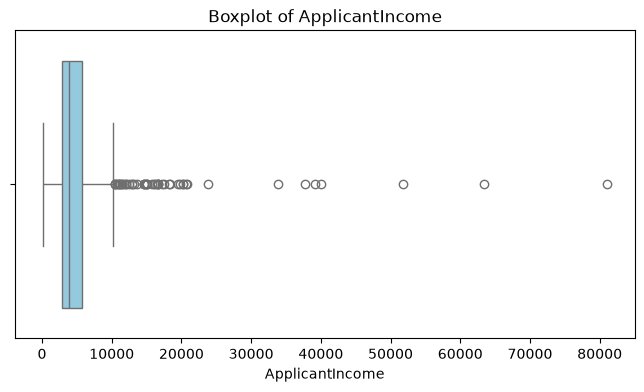

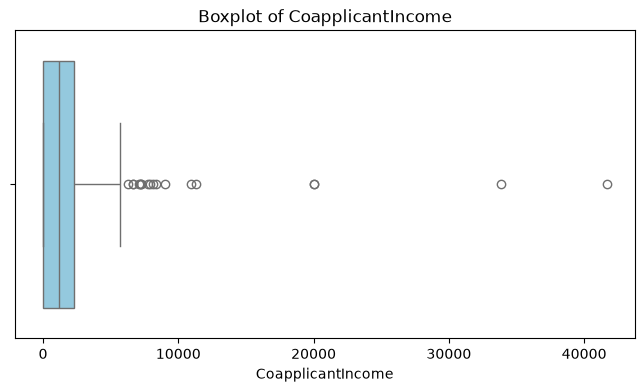

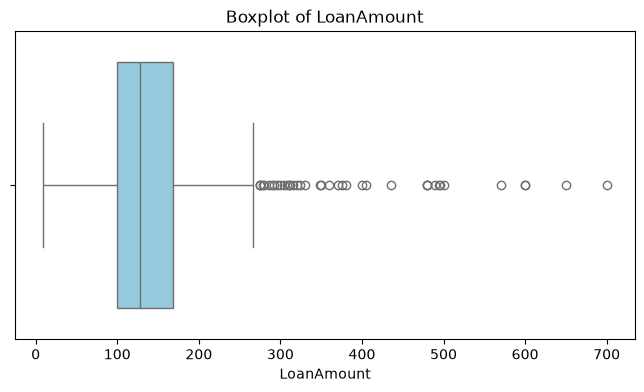

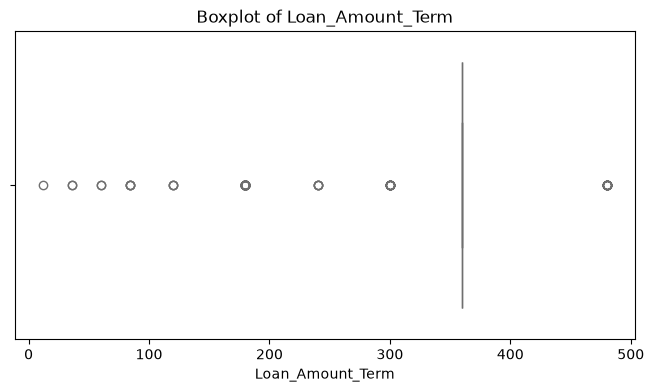

In [47]:
numerical_columns=["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]  #Identifying potential outliers using boxplots

for column in numerical_columns:
    
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[column], color="sky blue")
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()
    


### Finding

The boxplots indicate the presence of potential outliers in several numerical variables, particularly ApplicantIncome, CoapplicantIncome, and LoanAmount. These observations will be investigated further before deciding whether any treatment is necessary.

### Feature distributions

The distributions of the numerical features were examined to understand their spread, central tendency, and overall patterns. 

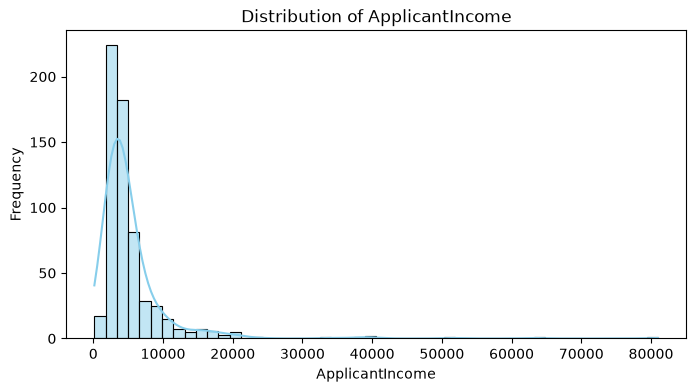

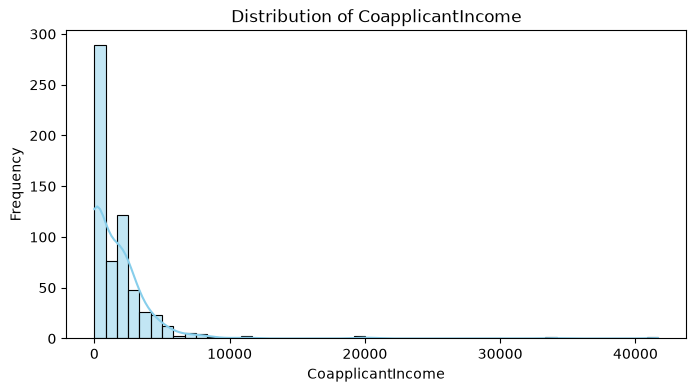

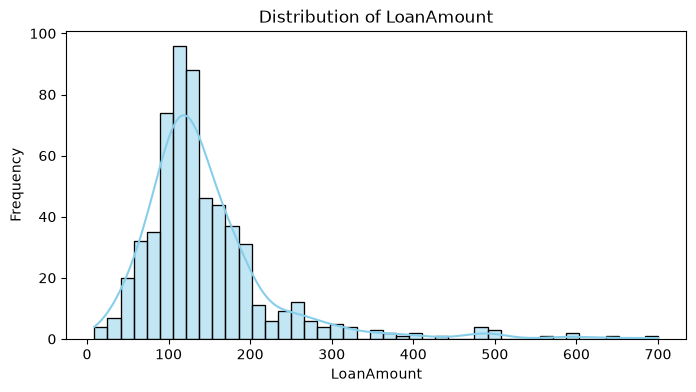

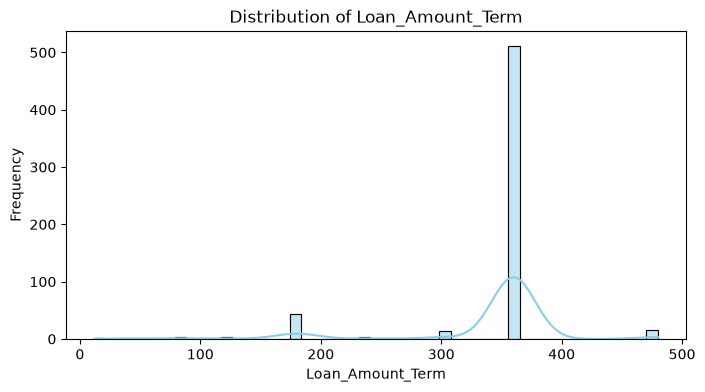

In [49]:
for column in numerical_columns:    #Plot distribution of numerical analysis
    
    plt.figure(figsize=(8,4))
    sns.histplot(data=df, x=column, kde=True, color="skyblue")
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

### Finding

The distribution plots show that the financial variables are not perfectly symmetrical and several display right-skewed distributions. This indicates that most observations are concentrated at lower values, with a smaller number of applicants having substantially higher values. These distribution patterns will be considered during preprocessing and modelling.

### Class imbalance

The distribution of the target variable is examined to determine whether the dataset contains an imbalance between approved and rejected loan applications.

In [33]:
df["Loan_Status"].value_counts()    #Checking the distribution of loan status

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [36]:
loan_status_percentage=df["Loan_Status"].value_counts(normalize=True)*100   #Checking the percentage distribution of loan status 

loan_status_percentage

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

### Finding

The target variable is moderately imbalanced, with 68.73% of applications being approved and 31.27% being rejected. This imbalance should be considered when evaluating predictive models to ensure that the model does not favour the majority class.

### Data quality improvements made

The initial data quality assessment identified missing values in seven variables, while no duplicate records or obvious categorical inconsistencies were found. Potential outliers were identified in several numerical variables, and moderate class imbalance was observed in the target variable. The identified issues will be addressed during the data-cleaning and machine-learning preparation stages.

# Part 2 – Advanced exploratory data analysis (EDA)

## 2.1 Introduction

The purpose of this section is to extend the exploratory analysis performed in week 2 by investigating deeper patterns, relationships, distributions, and interactions within the Loan Prediction dataset.

The analysis focuses on numerical distributions, categorical distributions, bivariate relationships, group comparisons, correlations, and relationships between applicant characteristics and the target variable, Loan_Status.

## 2.2 Numerical variable analysis

Numerical variables were examined using distribution plots and box plots to understand their central tendency, spread, skewness, and potential outliers. These analyses provide insight into the characteristics of applicant income, loan amount, loan term, and other numerical variables before examining their relationships with the target variable.

#### Histograms

Histograms are used to examine the frequency distribution of the numerical variables.

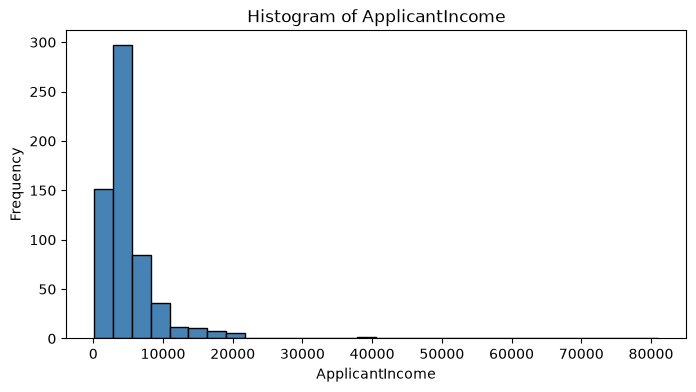

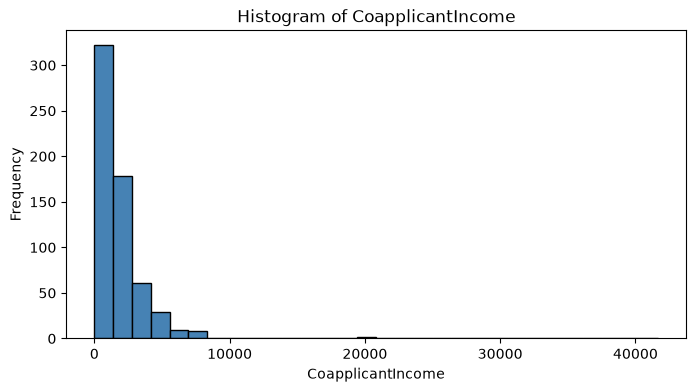

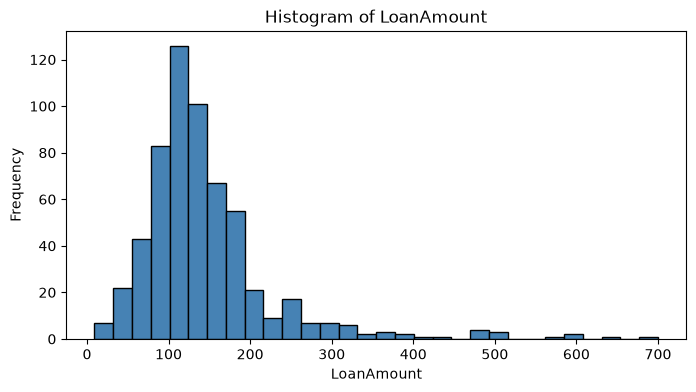

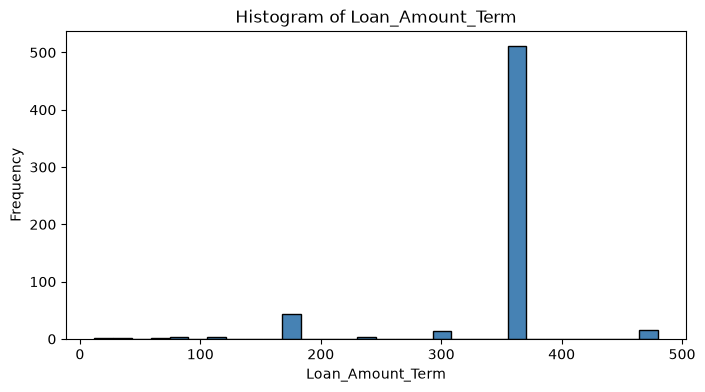

In [53]:
for column in numerical_columns:   #Plotting histgrams for numerical variables

    plt.figure(figsize=(8,4))
    plt.hist(df[column].dropna(), bins=30, color="steelblue", edgecolor="black")
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()
    

### Finding

The histograms show that ApplicantIncome, CoapplicantIncome, and LoanAmount are right-skewed, with most observations concentrated at lower values and fewer observations at higher values. Loan_Amount_Term has a highly concentrated distribution, with 360 months being the dominant loan term.

#### Boxplots

Boxplots are used to examine the spread of numerical variables and identify potential outliers.

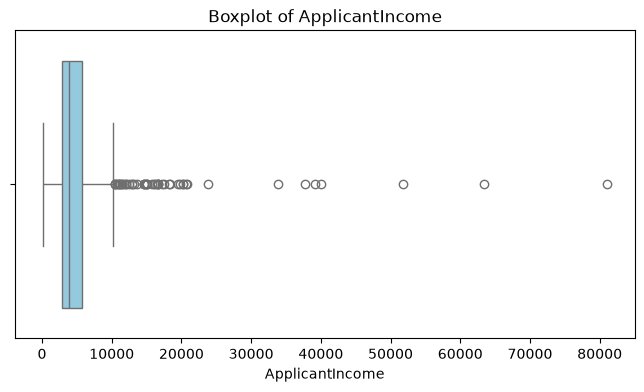

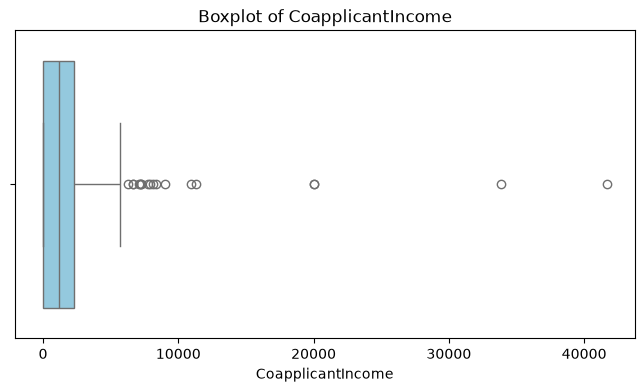

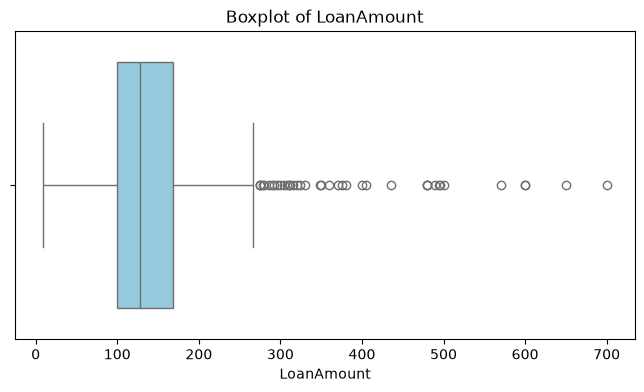

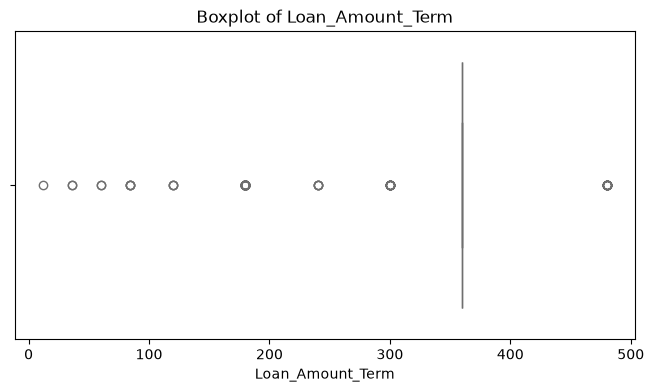

In [54]:
for column in numerical_columns:   # Plot boxplots for numerical variables
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column], color="skyblue")
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()

### Finding

The boxplots indicate potential outliers in ApplicantIncome, CoapplicantIncome, and LoanAmount, particularly on the upper end of their distributions. These findings are consistent with the right-skewed patterns observed in the histograms. Loan_Amount_Term is highly concentrated around 360 months, with several alternative term values appearing outside the main distribution. These observations will be considered during subsequent data preprocessing rather than being removed automatically.

#### Density plots

Density plots are used to provide a smoothed representation of the distributions of the numerical variables and to examine their overall shape and concentration.

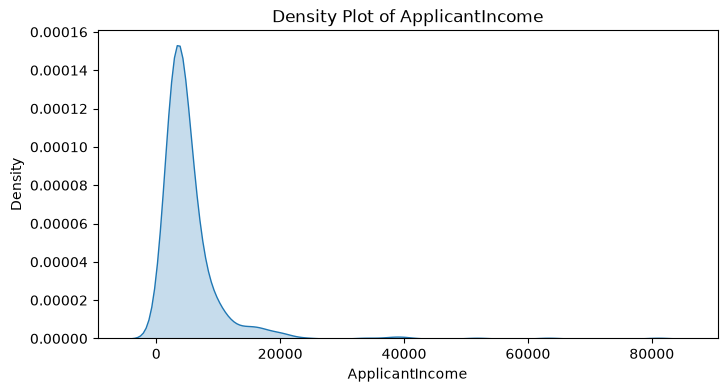

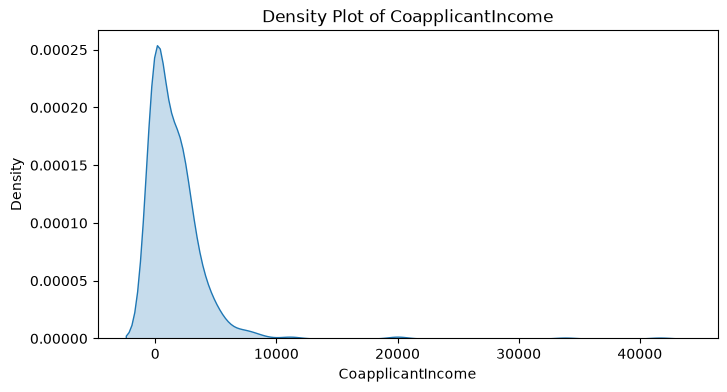

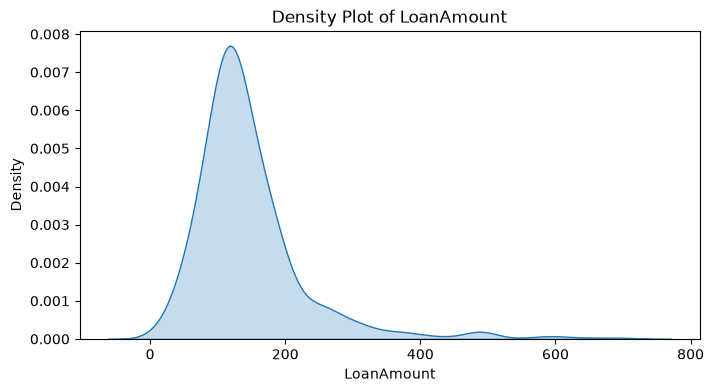

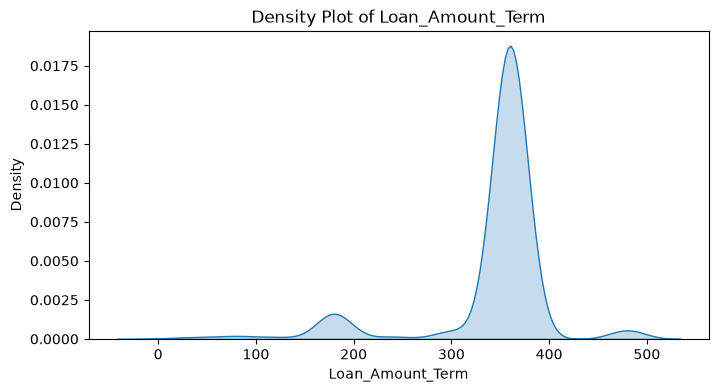

In [56]:
for column in numerical_columns:    #Plotting the density curve for numerical variables
    
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df, x=column, fill=True)
    plt.title(f"Density Plot of {column}")
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.show()

### Finding

The density plots show that ApplicantIncome, CoapplicantIncome, and LoanAmount are right-skewed, with most observations concentrated at lower values and longer tails extending toward higher values. Loan_Amount_Term has a strong concentration around 360 months, with smaller peaks representing alternative loan terms. These patterns indicate that the numerical variables have different distribution shapes and are not all normally distributed.

#### Distribution analysis

The distribution of the numerical variables is analysed using descriptive statistics to examine their central tendency, variability, and overall spread.

In [57]:
df[numerical_columns].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,614.000000,614.000000,592.000000,600.00000
mean,5403.459283,1621.245798,146.412162,342.00000
std,6109.041673,2926.248369,85.587325,65.12041
min,150.000000,0.000000,9.000000,12.00000
25%,2877.500000,0.000000,100.000000,360.00000
50%,3812.500000,1188.500000,128.000000,360.00000
75%,5795.000000,2297.250000,168.000000,360.00000
max,81000.000000,41667.000000,700.000000,480.00000


### Finding

The descriptive statistics support the distribution patterns observed in the visualizations. ApplicantIncome, CoapplicantIncome, and LoanAmount have means higher than their medians, confirming right-skewed distributions. ApplicantIncome and CoapplicantIncome also show substantial variability, as indicated by their large standard deviations. Loan_Amount_Term is highly concentrated around a median of 360 months. The summary also confirms missing observations in LoanAmount and Loan_Amount_Term.

## 2.3 Categorical variable analysis

Categorical variables were examined using frequency distributions and bar charts to understand the composition of the applicant population. The analysis considers variables such as Gender, Married, Education, Self_Employed, Dependents, Credit_History, and Property_Area.

#### 2.3.1 Frequency distributions

Frequency distributions are used to examine the number of observations within each category of the categorical variables.

In [66]:
categorical_columns = ["Gender","Married","Dependents","Education","Self_Employed","Property_Area","Loan_Status"]   #Selecting meaningful categorical columns for analysis

categorical_columns

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

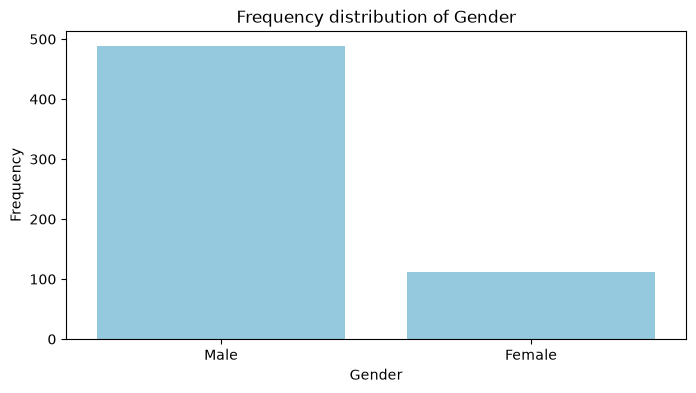

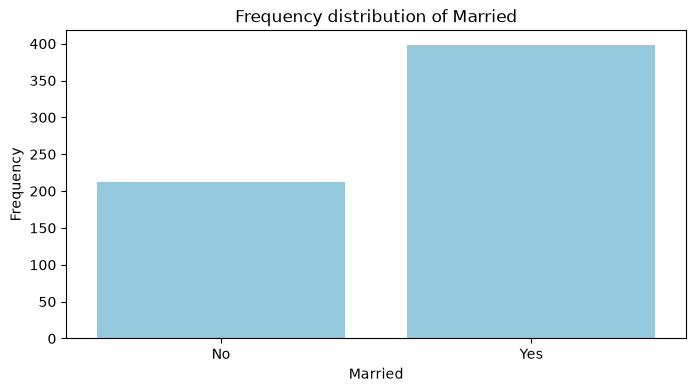

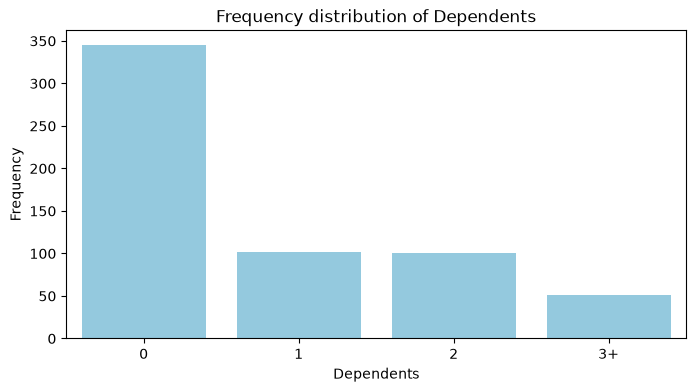

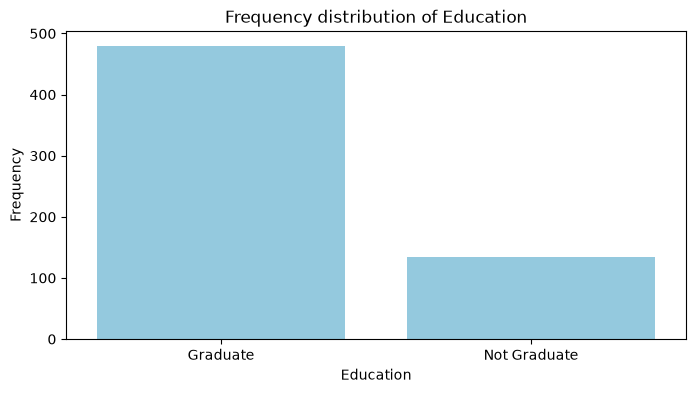

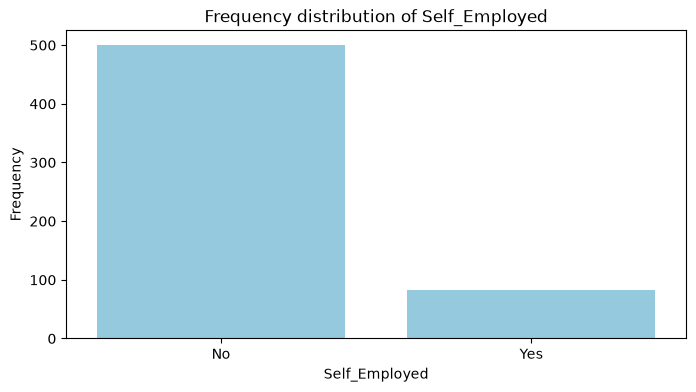

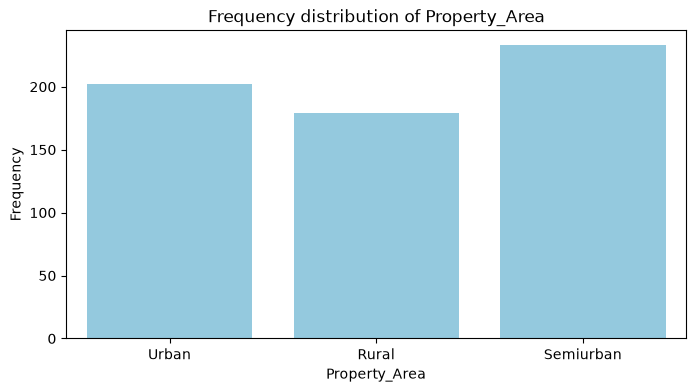

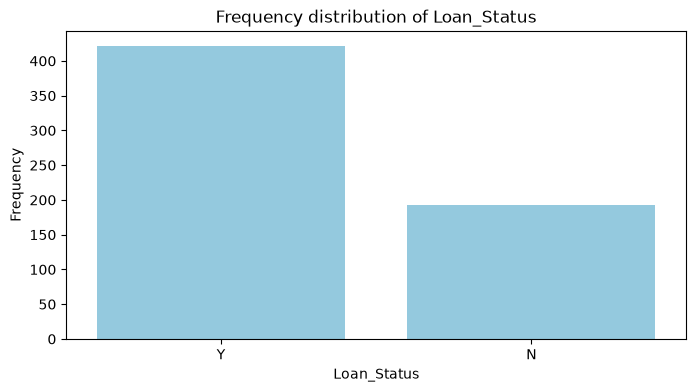

In [69]:
for column in categorical_columns:

    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=column, color="skyblue")
    plt.title(f"Frequency distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

### Finding

The frequency distributions show that the categorical variables have different levels of representation across their categories. The dataset contains more male applicants than female applicants, while married applicants are more common than unmarried applicants. Most applicants have no dependents, are graduates, and are not self-employed. Semiurban and urban applicants are more represented than rural applicants. Loan approvals are also more frequent than loan rejections, consistent with the class distribution observed earlier.

#### 2.3.2 Cross-tabulations

Cross-tabulations are used to examine the relationship between two categorical variables by comparing the frequency of observations across their categories.

In [71]:
gender_loan_crosstab=pd.crosstab(df["Gender"], df["Loan_Status"])    #Cross-tabulation of Gender and Loan Status

gender_loan_crosstab

Loan_Status,N,Y
Gender,,
Female,37,75
Male,150,339


### Finding

The cross-tabulation shows that approved applications are more frequent than rejected applications for both male and female applicants. Male applicants have higher approval and rejection counts, which is consistent with their greater representation in the dataset. Since the group sizes differ, percentage analysis is required to make a more meaningful comparison between the categories.

#### Percentage analysis

Percentage analysis is used to compare the distribution of loan outcomes within each category, allowing for a more meaningful comparison when the category sizes are different.

In [183]:
gender_loan_percentage=pd.crosstab(df["Gender"],df["Loan_Status"], normalize="index")*100     #Calculating percentage distribution of Loan Status within each gender

gender_loan_percentage

Loan_Status,N,Y
Gender,,
Female,33.035714,66.964286
Male,30.674847,69.325153


### Finding

The percentage analysis shows that 66.96% of female applicants and 69.33% of male applicants had their loans approved. The approval rates are relatively similar between the two groups, although male applicants have a slightly higher approval rate. This suggests that gender alone may not show a substantial difference in loan approval outcomes within this dataset.

#### Education vs Loan status

The relationship between education level and loan status is examined using a cross-tabulation to compare loan approval and rejection counts across education categories.

In [74]:
education_loan_crosstab=pd.crosstab(df["Education"], df["Loan_Status"])    #Cross-tabulation of education and Loan Status

education_loan_crosstab

Loan_Status,N,Y
Education,,
Graduate,140,340
Not Graduate,52,82


### Finding

The cross-tabulation shows that loan approvals are more frequent than rejections for both Graduate and Not Graduate applicants. Graduate applicants have higher approval and rejection counts, largely reflecting their greater representation in the dataset. Percentage analysis is therefore required to compare the loan approval rates between the two education groups.

In [76]:
education_loan_percentage=pd.crosstab(df["Education"], df["Loan_Status"], normalize="index")* 100   #Calculating percentage distribution of Loan Status within each education group

education_loan_percentage

Loan_Status,N,Y
Education,,
Graduate,29.166667,70.833333
Not Graduate,38.805970,61.194030


### Finding

The percentage analysis shows that 70.83% of Graduate applicants had their loans approved compared with 61.19% of Not Graduate applicants. Graduate applicants therefore have a higher observed approval rate, with a difference of approximately 9.64 percentage points between the two groups. This indicates a potential association between education level and loan approval outcomes in the dataset.

#### Married vs Loan status

The relationship between marital status and loan outcome is examined using cross-tabulation and percentage analysis to compare loan approval and rejection outcomes between married and unmarried applicants.

In [77]:
married_loan_crosstab=pd.crosstab(df["Married"], df["Loan_Status"])    #Cross-tabulation of married and Loan Status

married_loan_crosstab

Loan_Status,N,Y
Married,,
No,79,134
Yes,113,285


### Finding

The cross-tabulation shows that approved loan applications are more frequent than rejected applications for both married and unmarried applicants. Married applicants have higher approval and rejection counts, reflecting their greater representation in the dataset. Percentage analysis is therefore required to compare loan outcomes fairly between the two groups.

In [78]:
married_loan_percentage=pd.crosstab(df["Married"], df["Loan_Status"],normalize="index")* 100    #Calculating percentage distribution of Loan Status within each marital status group

married_loan_percentage

Loan_Status,N,Y
Married,,
No,37.089202,62.910798
Yes,28.391960,71.608040


### Finding

The percentage analysis shows that 62.91% of unmarried applicants had their loans approved, compared with 71.61% of married applicants. Married applicants therefore had a higher observed loan approval rate, with a difference of approximately 8.70 percentage points between the two groups. This suggests a potential association between marital status and loan approval outcomes in the dataset.

#### Dependents vs Loan status

The relationship between the number of dependents and loan outcome is examined using cross-tabulation to compare loan approval and rejection outcomes across different dependent categories.

In [79]:
Dependents_loan_crosstab=pd.crosstab(df["Dependents"], df["Loan_Status"])    #Cross-tabulation of Dependents and Loan Status
Dependents_loan_crosstab

Loan_Status,N,Y
Dependents,,
0,107,238
1,36,66
2,25,76
3+,18,33


### Finding

The cross-tabulation shows that loan approvals are more frequent than rejections across all dependent categories. Applicants with no dependents have the highest approval and rejection counts, reflecting their greater representation in the dataset. Since the sizes of the dependent groups differ, percentage analysis is required to make a fair comparison of loan outcomes across the categories.

In [82]:
Dependents_loan_percentage=pd.crosstab(df["Dependents"], df["Loan_Status"], normalize="index")*100    #Calculating percentage distribution of Loan Status within each dependent group
Dependents_loan_percentage

Loan_Status,N,Y
Dependents,,
0,31.014493,68.985507
1,35.294118,64.705882
2,24.752475,75.247525
3+,35.294118,64.705882


### Finding

The percentage analysis shows differences in loan approval rates across the dependent categories. Applicants with 2 dependents have the highest observed approval rate at 75.25%, while applicants with 1 dependent and 3+ dependents have the lowest approval rates at 64.71%. Applicants with 0 dependents have an approval rate of 68.99%. These results suggest a potential association between the number of dependents and loan approval outcomes, although the observed differences do not establish a causal relationship.

#### Self-employed vs Loan status

The relationship between self-employment status and loan outcome is examined using cross-tabulation to compare loan approval and rejection outcomes between self-employed and non-self-employed applicants.

In [83]:
Self_Employed_loan_crosstab=pd.crosstab(df["Self_Employed"], df["Loan_Status"])    #Cross-tabulation of Self_Employed and Loan Status
Self_Employed_loan_crosstab

Loan_Status,N,Y
Self_Employed,,
No,157,343
Yes,26,56


### Finding

The cross-tabulation shows that approved loan applications are more frequent than rejected applications for both self-employed and non-self-employed applicants. Non-self-employed applicants have higher approval and rejection counts, reflecting their greater representation in the dataset. Percentage analysis is therefore required to make a fair comparison between the two groups.

In [84]:
Self_Employed_loan_percentage=pd.crosstab(df["Self_Employed"], df["Loan_Status"], normalize="index")*100    #Calculating percentage distribution of Loan Status within each self-employment group
Self_Employed_loan_percentage

Loan_Status,N,Y
Self_Employed,,
No,31.400000,68.600000
Yes,31.707317,68.292683


### Finding

The percentage analysis shows that 68.60% of non-self-employed applicants had their loans approved, compared with 68.29% of self-employed applicants. The approval rates are almost identical, with a difference of only 0.31 percentage points. This suggests that self-employment status shows very little difference in observed loan approval outcomes in this dataset.

#### Property area vs Loan status

The relationship between property area and loan outcome is examined using cross-tabulation to compare loan approval and rejection outcomes across Urban, Rural, and Semiurban property areas.

In [86]:
property_area_loan_crosstab=pd.crosstab(df["Property_Area"], df["Loan_Status"])    #Cross-tabulation of Self_Employed and Loan Status
property_area_loan_crosstab

Loan_Status,N,Y
Property_Area,,
Rural,69,110
Semiurban,54,179
Urban,69,133


### Finding

The cross-tabulation shows that approved loan applications are more frequent than rejected applications across all three property area categories. Semiurban applicants have the highest number of approved applications, while Rural and Urban applicants have similar numbers of rejected applications. Since the number of applicants differs across the property area categories, percentage analysis is required to make a fair comparison of loan outcomes.

In [87]:
property_area_loan_percentage=pd.crosstab(df["Property_Area"], df["Loan_Status"], normalize="index")* 100    #Calculating percentage distribution of Loan Status within each property area group
property_area_loan_percentage

Loan_Status,N,Y
Property_Area,,
Rural,38.547486,61.452514
Semiurban,23.175966,76.824034
Urban,34.158416,65.841584


### Finding

The percentage analysis shows differences in loan approval rates across property areas. Semiurban applicants have the highest observed approval rate at 76.82%, followed by Urban applicants at 65.84%, while Rural applicants have the lowest approval rate at 61.45%. This indicates a potential association between property area and loan approval outcomes in the dataset.

## 2.4 Bivariate analysis

Bivariate analysis was performed to investigate relationships between pairs of variables. Both numerical and categorical combinations were considered to identify patterns that may be relevant to loan approval decisions.

### 2.4.1 Numerical vs Numerical analysis

The relationship between ApplicantIncome and LoanAmount is examined using a scatter plot to determine whether higher applicant income is associated with larger loan amounts.

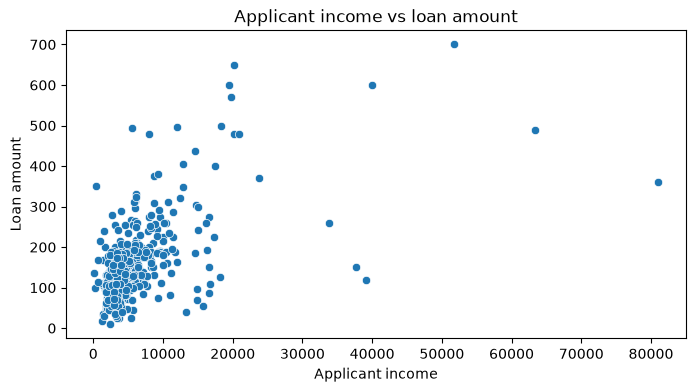

In [88]:
plt.figure(figsize=(8,4))                                        #Scatter plot grath of Applicant Income vs Loan Amount    
sns.scatterplot(data=df, x="ApplicantIncome", y="LoanAmount")
plt.title("Applicant income vs loan amount")
plt.xlabel("Applicant income")
plt.ylabel("Loan amount")
plt.show()

### Finding

The scatter plot shows a generally positive relationship between ApplicantIncome and LoanAmount, as higher applicant incomes tend to be associated with larger loan amounts. However, the relationship is not strongly linear, as the observations are widely dispersed. Most applications are concentrated at lower income and loan amount values, with several extreme observations at higher values.

In [89]:
df[["ApplicantIncome","LoanAmount"]].corr()  #Calculating the correlation between ApplicantIncome and LoanAmount

,ApplicantIncome,LoanAmount
ApplicantIncome,1.000000,0.570909
LoanAmount,0.570909,1.000000


### Finding

The correlation coefficient between ApplicantIncome and LoanAmount is 0.5709, indicating a moderate positive linear relationship. This suggests that applicants with higher incomes generally tend to receive larger loan amounts. However, the correlation is not strong enough to indicate a close linear relationship, which is consistent with the dispersion observed in the scatter plot.

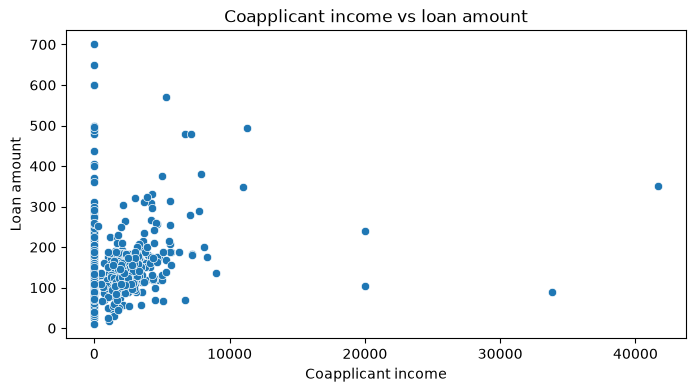

In [90]:
plt.figure(figsize=(8,4))                                        #Scatter plot grath of Coapplicant Income vs Loan Amount    
sns.scatterplot(data=df, x="CoapplicantIncome", y="LoanAmount")
plt.title("Coapplicant income vs loan amount")
plt.xlabel("Coapplicant income")
plt.ylabel("Loan amount")
plt.show()

### Finding

The scatter plot shows that most observations are concentrated at lower CoapplicantIncome values, particularly near zero. There is a slight positive tendency between CoapplicantIncome and LoanAmount, although the observations are widely dispersed and the relationship does not appear strongly linear. Several observations with unusually high coapplicant income values are also visible.

In [91]:
df[["CoapplicantIncome","LoanAmount"]].corr()

,CoapplicantIncome,LoanAmount
CoapplicantIncome,1.000000,0.188619
LoanAmount,0.188619,1.000000


### Finding

The correlation coefficient between CoapplicantIncome and LoanAmount is 0.1886, indicating a weak positive linear relationship. This suggests that higher coapplicant income is only slightly associated with higher loan amounts. The weak correlation is consistent with the wide dispersion of observations in the scatter plot, indicating that CoapplicantIncome alone has a limited linear relationship with LoanAmount.

### 2.4.2 Numerical vs Categorical analysis

The relationship between ApplicantIncome and Loan_Status is examined using a boxplot to compare the distribution of applicant income across approved and rejected loan applications.

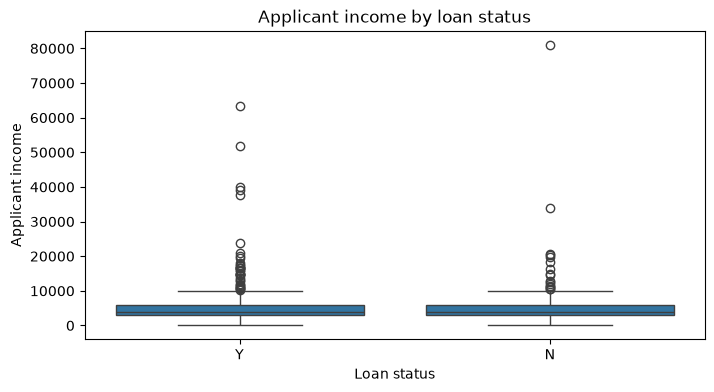

In [92]:
plt.figure(figsize=(8,4))                                        #Boxplot graph of ApplicantIncome by Loan Status  
sns.boxplot(data=df, x="Loan_Status", y="ApplicantIncome")
plt.title("Applicant income by loan status")
plt.xlabel("Loan status")
plt.ylabel("Applicant income")
plt.show()

### Finding

The boxplot shows the distribution of ApplicantIncome across approved and rejected loan applications. The income distributions of the two loan-status groups show considerable overlap, although several high-income observations appear as outliers. The presence of these extreme values indicates substantial variation in applicant income across both loan outcome groups.

In [93]:
df.groupby("Loan_Status")["ApplicantIncome"].describe()                  #Summary statistics of ApplicantIncome by Loan Status

,count,mean,std,min,25%,50%,75%,max
Loan_Status,,,,,,,,
N,192.0,5446.078125,6819.558528,150.0,2885.0,3833.5,5861.25,81000.0
Y,422.0,5384.068720,5765.441615,210.0,2877.5,3812.5,5771.50,63337.0


### Finding

The summary statistics show that ApplicantIncome is similar between rejected and approved loan applications. The mean income is 5,446.08 for rejected applications and 5,384.07 for approved applications, while the median incomes are 3,833.50 and 3,812.50, respectively. The relatively small differences suggest that applicant income alone does not show a substantial difference between the two loan-status groups. However, the higher standard deviation and maximum income for rejected applications indicate greater variability and the presence of extreme income values.

#### Loan amount vs Loan status

The relationship between LoanAmount and Loan_Status is examined using a boxplot to compare the distribution of loan amounts between approved and rejected loan applications.

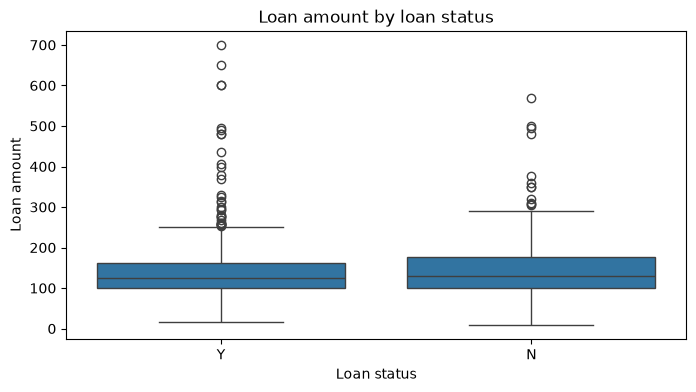

In [94]:
plt.figure(figsize=(8,4))                                        #Boxplot graph of loanAmount by Loan Status  
sns.boxplot(data=df, x="Loan_Status", y="LoanAmount")
plt.title("Loan amount by loan status")
plt.xlabel("Loan status")
plt.ylabel("Loan amount")
plt.show()

### Finding

The boxplot shows that the distributions of LoanAmount for approved and rejected applications overlap considerably. Both loan-status groups contain observations with relatively high loan amounts, with several values appearing as potential outliers. The substantial overlap suggests that LoanAmount alone may not clearly distinguish between approved and rejected loan applications.

In [95]:
df.groupby("Loan_Status")["LoanAmount"].describe()           #Summary statistics of LoanAmount by Loan Status


,count,mean,std,min,25%,50%,75%,max
Loan_Status,,,,,,,,
N,181.0,151.220994,85.862783,9.0,100.0,129.0,176.0,570.0
Y,411.0,144.294404,85.484607,17.0,100.0,126.0,161.0,700.0


### Finding

The summary statistics show that LoanAmount has similar distributions for rejected and approved applications. The mean loan amount is 151.22 for rejected applications and 144.29 for approved applications, while the median values are 129.00 and 126.00, respectively. The standard deviations are also very similar at 85.86 and 85.48. These results indicate that LoanAmount alone does not show a substantial difference between the two loan-status groups, which is consistent with the considerable overlap observed in the boxplot.

#### Credit history vs Loan status

The relationship between Credit_History and Loan_Status is examined to compare loan approval and rejection outcomes across applicants with different credit history categories.

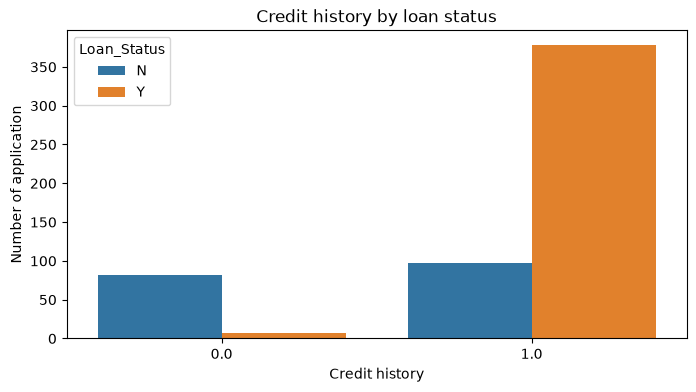

In [96]:
plt.figure(figsize=(8,4))                                       
sns.countplot(data=df, x="Credit_History", hue="Loan_Status")
plt.title("Credit history by loan status")
plt.xlabel("Credit history")
plt.ylabel("Number of application")
plt.show()

### Finding

The count plot shows a clear difference in loan outcomes across the Credit_History categories. Applicants with a positive credit history (Credit_History = 1) account for substantially more approved applications than rejected applications. In contrast, applicants with no positive credit history (Credit_History = 0) have considerably fewer approvals and a larger proportion of rejected applications. This indicates that Credit_History may have an important association with loan approval outcomes in the dataset.

In [98]:
credit_history_loan_percentage=pd.crosstab(df["Credit_History"],df["Loan_Status"], normalize="index")* 100

credit_history_loan_percentage

Loan_Status,N,Y
Credit_History,,
0.0,92.134831,7.865169
1.0,20.421053,79.578947


### Finding

The percentage analysis shows a strong association between Credit_History and Loan_Status. Among applicants with Credit_History = 0, 92.13% of loan applications were rejected and only 7.87% were approved. In contrast, applicants with Credit_History = 1 had an approval rate of 79.58%, while 20.42% were rejected. This substantial difference suggests that Credit_History is an important factor associated with loan approval outcomes in the dataset.

### 2.4.3 Categorical vs Categorical analysis

The relationship between Gender and Education is examined to determine how educational attainment is distributed across male and female applicants. A cross-tabulation and percentage analysis are used to compare the two categorical variables.

In [100]:
gender_education_crosstab=pd.crosstab(df["Gender"],df["Education"])   #Cross-tabulation of Gender and Education
 
gender_education_crosstab

Education,Graduate,Not Graduate
Gender,,
Female,92,20
Male,376,113


### Finding

The cross-tabulation shows that most applicants in both gender categories are graduates. Among female applicants, 92 are graduates and 20 are not graduates, while among male applicants, 376 are graduates and 113 are not graduates. The higher counts for male applicants reflect their greater representation in the dataset. Percentage analysis is therefore needed to compare the educational distribution between the two gender groups fairly.

In [101]:
gender_education_percentage=pd.crosstab(df["Gender"],df["Education"], normalize="index")* 100       #Calculating percentage distribution of Education within each gender group
 
gender_education_percentage

Education,Graduate,Not Graduate
Gender,,
Female,82.142857,17.857143
Male,76.891616,23.108384


### Finding

The percentage analysis shows that the majority of applicants in both gender groups are graduates. Female applicants have a graduate proportion of 82.14%, compared with 76.89% among male applicants. The proportion of non-graduates is 17.86% for females and 23.11% for males. This indicates a relatively similar educational distribution between the two gender groups, with females showing a slightly higher proportion of graduates in the dataset.

In [102]:
gender_married_crosstab = pd.crosstab(df["Gender"], df["Married"])  #Cross-tabulation of Gender and Married status

gender_married_crosstab

Married,No,Yes
Gender,,
Female,80,31
Male,130,357


### Finding

The cross-tabulation shows differences in marital status across the gender categories. Among female applicants, 80 are not married and 31 are married, while among male applicants, 130 are not married and 357 are married. The higher counts for male applicants reflect their greater representation in the dataset. Percentage analysis is therefore needed to compare marital status distributions between the two gender groups fairly.

In [103]:
gender_married_percentage = pd.crosstab(df["Gender"],df["Married"],normalize="index") * 100   #Calculating percentage distribution of Married status within each gender group

gender_married_percentage

Married,No,Yes
Gender,,
Female,72.072072,27.927928
Male,26.694045,73.305955


### Finding

The percentage analysis shows a clear difference in marital status distribution between male and female applicants. Among female applicants, 72.07% are not married and 27.93% are married. In contrast, 73.31% of male applicants are married and 26.69% are not married. This indicates a noticeable association between Gender and Married status in the dataset.

In [104]:
married_selfemployed_crosstab = pd.crosstab(df["Married"],df["Self_Employed"])    #Cross-tabulation of Married and Self-Employed status

married_selfemployed_crosstab

Self_Employed,No,Yes
Married,,
No,171,28
Yes,326,54


### Finding

The cross-tabulation shows that non-self-employed applicants are more numerous than self-employed applicants in both marital-status groups. Among unmarried applicants, 171 are not self-employed and 28 are self-employed, while among married applicants, 326 are not self-employed and 54 are self-employed. Since the number of married and unmarried applicants differs substantially, percentage analysis is required to compare self-employment status between the two groups fairly.

In [105]:
married_selfemployed_percentage = pd.crosstab(df["Married"],df["Self_Employed"],normalize="index") * 100   # Calculating percentage distribution of Self-Employed status within each marital-status group

married_selfemployed_percentage

Self_Employed,No,Yes
Married,,
No,85.929648,14.070352
Yes,85.789474,14.210526


### Finding

The percentage analysis shows that the proportion of self-employed applicants is very similar between the two marital status groups. Among unmarried applicants, 14.07% are self-employed, compared with 14.21% among married applicants. Similarly, the proportion of non-self-employed applicants is almost identical at 85.93% and 85.79%, respectively. This suggests that there is very little difference in self-employment status between married and unmarried applicants in this dataset.
    

## 2.5 Target variable analysis

The target variable, Loan_Status, was examined to understand the distribution of approved and rejected loan applications. This analysis is important because it shows the balance of the target variable and provides context for subsequent statistical analysis and predictive modelling.

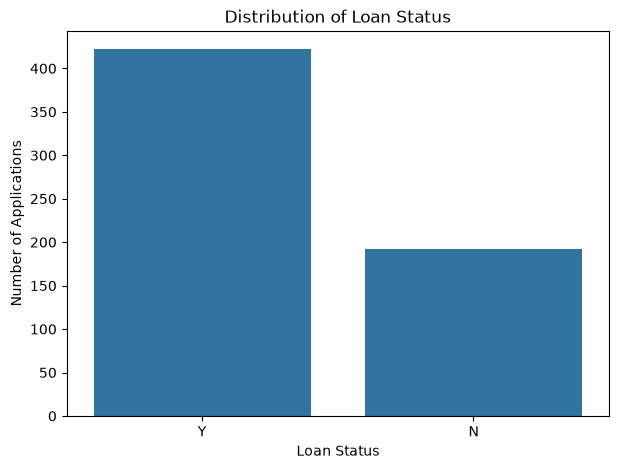

In [184]:
loan_status_counts = df["Loan_Status"].value_counts()     #Couning the number of applications in each Loan_Status category

plt.figure(figsize=(7, 5))   #Creating the bar chart
sns.barplot( x=loan_status_counts.index, y=loan_status_counts.values)

plt.title("Distribution of Loan Status")   #Displaying the graph
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.show()

### Finding

The distribution shows that 422 loan applications were approved (Y), while 192 applications were rejected (N). Approved applications represent approximately 68.73% of the dataset, compared with 31.27% rejected applications.

The target variable is moderately imbalanced because approved applications are more common than rejected applications. This imbalance should be considered when evaluating predictive models in later stages.

## 2.6 Correlation analysis

Correlation analysis was performed to examine the strength and direction of relationships between numerical variables. Pearson correlation coefficients were used to identify potentially strong relationships and possible redundancy between numerical features.

Particular attention was given to relationships involving ApplicantIncome, CoapplicantIncome, LoanAmount, TotalIncome, and DebtToIncomeRatio.

In [186]:
correlation_columns = ["ApplicantIncome", "CoapplicantIncome","LoanAmount", "Loan_Amount_Term",    #Selecting numerical variables for correlation analysis
                       "Credit_History"]

correlation_matrix = df[correlation_columns].corr()    #Calculating the correlation matrix

correlation_matrix    #Displaying the correlation matrix

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.570909,-0.045306,-0.014715
CoapplicantIncome,-0.116605,1.000000,0.188619,-0.059878,-0.002056
LoanAmount,0.570909,0.188619,1.000000,0.039447,-0.008433
Loan_Amount_Term,-0.045306,-0.059878,0.039447,1.000000,0.001470
Credit_History,-0.014715,-0.002056,-0.008433,0.001470,1.000000


### Correlation matrix – Initial findings

The correlation matrix shows the Pearson correlation coefficients between the numerical variables. Most of the relationships in this section are weak, with correlation coefficients close to zero.

The strongest relationship shown in this portion of the matrix is between ApplicantIncome and LoanAmount, with a correlation coefficient of 0.5709. This indicates a moderate positive relationship, meaning that applicants with higher incomes tend to have higher loan amounts.

CoapplicantIncome has a weak positive correlation with LoanAmount (r = 0.1886), while ApplicantIncome and CoapplicantIncome have a weak negative correlation (r = -0.1166).

The correlations involving Loan_Amount_Term and Credit_History are generally very weak, suggesting limited linear relationships with the other numerical variables in this part of the matrix.

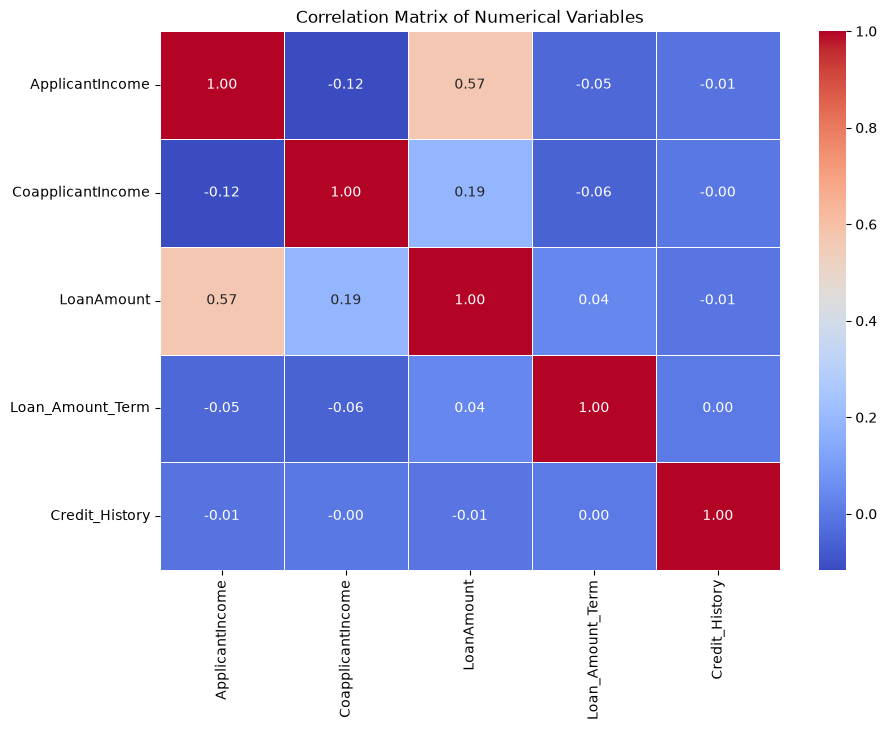

In [187]:
plt.figure(figsize=(10, 7))   #plotting the correlation matrix as a heatmap

sns.heatmap(correlation_matrix, annot=True,
            cmap="coolwarm", fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Matrix of Numerical Variables")  #Displaying the created graph
plt.show()

### Correlation analysis findings

The correlation heatmap shows the strength and direction of the linear relationships among ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, and Credit_History.

The strongest relationship is between ApplicantIncome and LoanAmount, with a correlation coefficient of 0.5709, indicating a moderate positive relationship. This suggests that applicants with higher incomes tend to have higher loan amounts.

CoapplicantIncome and LoanAmount show a weak positive correlation (r = 0.1886), while ApplicantIncome and CoapplicantIncome have a weak negative correlation (r = -0.1166).

The correlations involving Loan_Amount_Term and Credit_History are generally very weak, with coefficients close to zero. This indicates that these variables have limited linear relationships with the other numerical variables included in the analysis.

Overall, no very strong correlations were identified among these five variables. The moderate relationship between ApplicantIncome and LoanAmount will be considered in the subsequent statistical and feature selection analyses.

## 2.7 Multivariate analysis

Multivariate analysis is used to investigate relationships among three or more variables simultaneously. This helps provide a deeper understanding of how applicant characteristics and financial variables interact with loan approval outcomes.

### 2.7.1 Applicant income, loan amount and loan status

A scatter plot was used to examine the relationship between ApplicantIncome and LoanAmount, while Loan_Status was used to distinguish between approved and rejected loan applications. This multivariable comparison helps assess whether income and requested loan amount show different patterns across loan approval outcomes.

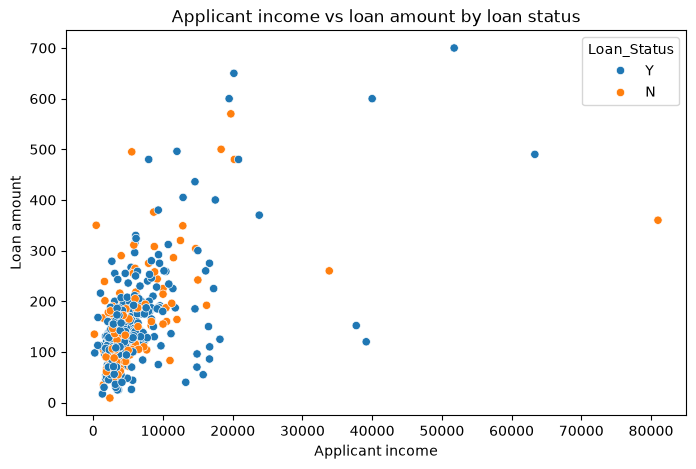

In [108]:
plt.figure(figsize=(8,5))                                                  #Multivariate scatter plot graph of ApplicantIncome, LoanAmount and Loan_Status                                              
sns.scatterplot(data=df, x="ApplicantIncome", y="LoanAmount", hue="Loan_Status")
plt.title("Applicant income vs loan amount by loan status")
plt.xlabel("Applicant income")
plt.ylabel("Loan amount")
plt.show()

### Finding

The multivariate scatter plot shows the relationship between ApplicantIncome and LoanAmount while distinguishing applications by Loan_Status. Approved and rejected applications are distributed across similar ranges of income and loan amounts, with substantial overlap between the two groups. The plot also shows several observations with unusually high income and loan amounts. Overall, ApplicantIncome and LoanAmount show a positive relationship, but these two variables alone do not clearly separate approved from rejected applications.

### 2.7.2 Credit history, Applicant income and Loan status

The combined relationship between Credit_History, ApplicantIncome, and Loan_Status is examined to determine whether applicant income and credit history together show different patterns in loan approval outcomes. This provides a multivariate view of how applicant income and credit history relate to loan approval outcomes.

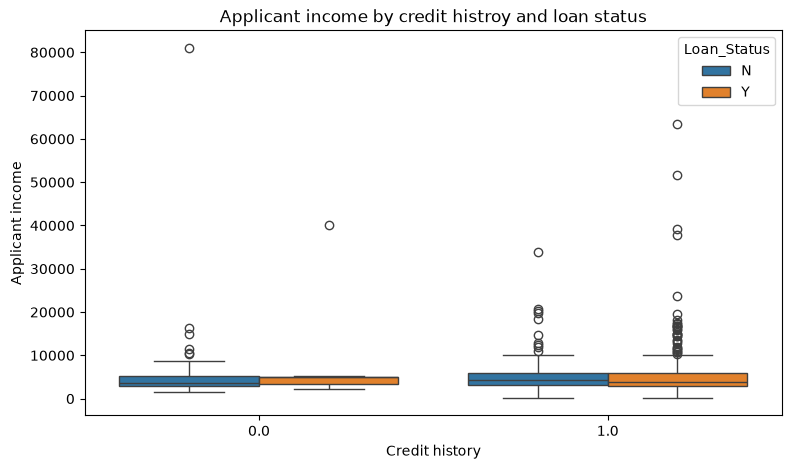

In [110]:
plt.figure(figsize=(9,5))                                                        #Multivariate boxplot graph of ApplicantIncome by Credit History and Loan Status                                     
sns.boxplot(data=df, x="Credit_History", y="ApplicantIncome", hue="Loan_Status")
plt.title("Applicant income by credit histroy and loan status")
plt.xlabel("Credit history")
plt.ylabel("Applicant income")
plt.show()

### Finding

The boxplot shows differences in ApplicantIncome across Credit_History and Loan_Status categories. Applicants with a positive credit history (Credit_History = 1) contain both approved and rejected applications, while applicants with Credit_History = 0 show substantially fewer approved applications. The income distributions within the groups overlap considerably, and several high-income observations appear as potential outliers. Overall, the plot suggests that Credit_History provides a clearer separation of loan outcomes than ApplicantIncome alone.

### 2.7.3 Property area, Loan amount and Loan status

The relationship among Property_Area, LoanAmount, and Loan_Status is examined to determine whether loan amounts and approval outcomes vary across different property area categories.

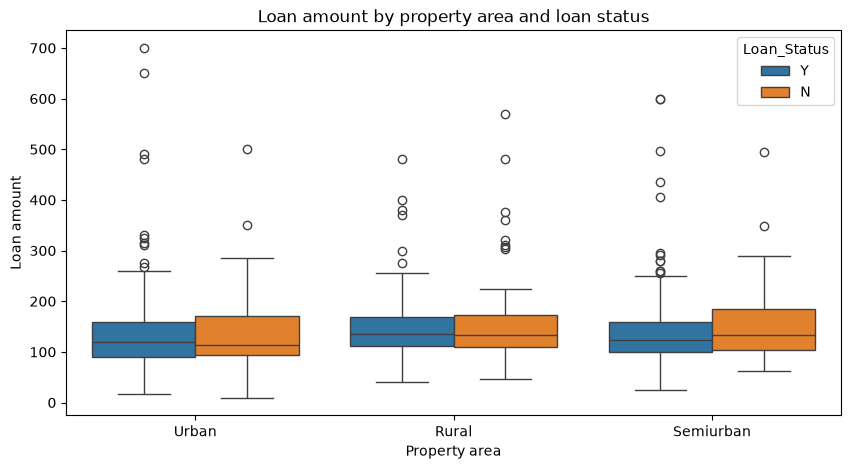

In [111]:
plt.figure(figsize=(10,5))                                          #Multivariate boxplot graph of LoanAmount by Property Area and Loan Status                                        
sns.boxplot(data=df, x="Property_Area", y="LoanAmount", hue="Loan_Status")
plt.title("Loan amount by property area and loan status")
plt.xlabel("Property area")
plt.ylabel("Loan amount")
plt.show()

### Finding

The boxplot shows that loan amounts vary across the different property-area categories and loan status groups. Approved and rejected applications show some overlap in their loan amount distributions within each property area. Semiurban applicants generally show a wider range of loan amounts, while several high loan amounts appear as potential outliers across the groups. Overall, Property_Area does not appear to create a clear separation between approved and rejected applications based on LoanAmount alone.

## 2.8 Group comparisons

Group comparison analysis was conducted to compare numerical applicant and loan characteristics across different categories of Loan_Status. Box plots were used to compare the distributions, medians, spread, and potential outliers between approved and rejected loan applications.

This analysis helps identify whether applicant characteristics differ between loan approval groups and provides a visual basis for the statistical tests conducted in Part 3.

### 2.8.1 Loan amount by Loan status

The box plot compares the distribution of LoanAmount between approved and rejected loan applications. The comparison allows differences in the median, spread, and potential outliers of loan amounts between the two groups to be observed.

The visualisation provides an initial indication of whether loan amount differs between approved and rejected applications. This relationship will be further evaluated using statistical hypothesis testing in Part 3.

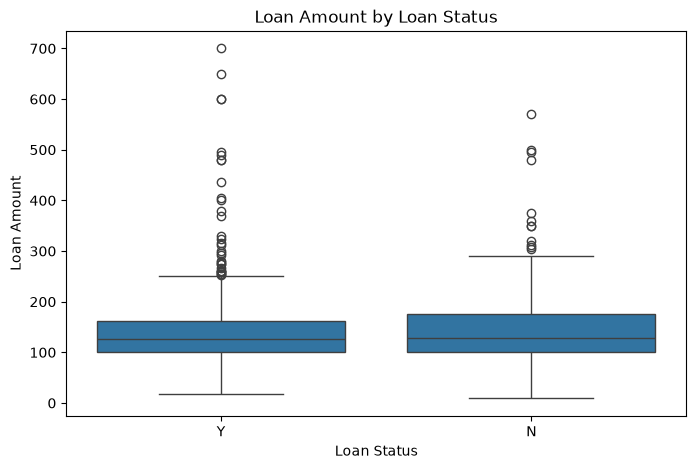

In [188]:
plt.figure(figsize=(8, 5))          #Creating a boxplot graph
sns.boxplot(data=df, x="Loan_Status", y="LoanAmount")

plt.title("Loan Amount by Loan Status") #Displaying the created graph
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.show()

### Finding

The box plot compares the distribution of LoanAmount between approved (Y) and rejected (N) loan applications. The two groups show some differences in their distributions, including differences in their central tendency and spread. Several potential outliers are also visible, particularly among applicants with relatively high loan amounts.

The visual comparison suggests that loan amount may differ between the two loan status groups. However, the statistical significance of this difference should be determined using the appropriate hypothesis test in Part 3.

### 2.8.2 Applicant income by loan status

The box plot compares ApplicantIncome between approved and rejected loan applications. The distributions provide a visual comparison of the central tendency, variability, and potential outliers in applicant income across the two loan status groups.

The visual comparison provides context for the Independent T-Test conducted in Part 3, which formally evaluates whether the mean applicant income differs significantly between approved and rejected applications.

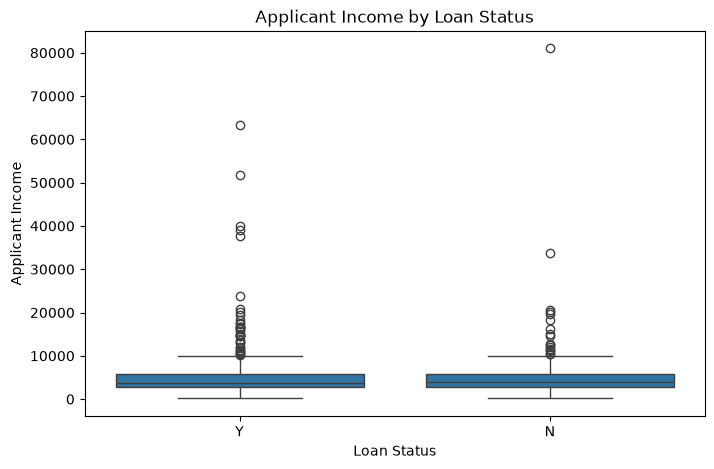

In [189]:
plt.figure(figsize=(8, 5))     #Creating a boxplot graph

sns.boxplot(data=df, x="Loan_Status", y="ApplicantIncome"
)

plt.title("Applicant Income by Loan Status")   #Displaying the created graph
plt.xlabel("Loan Status")
plt.ylabel("Applicant Income")
plt.show()

### Finding

The box plot shows the distribution of ApplicantIncome across the two Loan_Status groups. Both approved (Y) and rejected (N) applications show considerable variation in applicant income, with several high income observations appearing as potential outliers.

The distributions of applicant income across the two loan status groups appear broadly similar, although some differences in the median and spread can be observed. This suggests that applicant income may not clearly distinguish between approved and rejected applications based on the visual analysis alone. Further statistical analysis will be used in Part 3 to determine whether any observed differences are statistically significant.

# Part 3 – Statistical hypothesis testing and validation

Statistical analysis is performed to determine whether the relationships and differences observed during the exploratory data analysis are statistically significant. Four statistical tests are conducted based on the characteristics of the variables in the dataset: Pearson Correlation, Chi-Square Test, Independent T-Test, and Mann-Whitney U Test.

For each statistical test, the objective, null hypothesis (H₀), alternative hypothesis (H₁), test statistic, p-value, interpretation, and business implication are reported. A significance level of 5% (α = 0.05) is used to determine statistical significance.

## 3.1 Pearson correlation analysis

### Objective

The objective of the Pearson correlation analysis is to determine whether there is a statistically significant linear relationship between ApplicantIncome and LoanAmount.

### Hypotheses

- H₀: There is no statistically significant linear relationship between ApplicantIncome and LoanAmount (ρ = 0).
 
- H₁: There is a statistically significant linear relationship between ApplicantIncome and LoanAmount (ρ ≠ 0).

In [113]:
from scipy.stats import pearsonr    #Importing pearsonr from scipy.stats

correlation_data=df[["ApplicantIncome","LoanAmount"]].dropna()    #Removing the missing values from the created two variables

r_statistic, p_value=pearsonr(correlation_data["ApplicantIncome"],correlation_data["LoanAmount"])   #Performing the correlation test

print("Pearson correlation coefficient(r):",r_statistic)   #Displaying the two results so we get from the function pearsonr c
print("p-value:",p_value)



Pearson correlation coefficient(r): 0.5709090389885667
p-value: 1.6783336847935366e-52


### Test statistic and p-value

- Test statistic (r): 0.5709
- p-value: 1.6783 × 10⁻⁵²
- Significance level (α): 0.05

### Interpretation

The Pearson correlation coefficient of 0.5709 indicates a moderate positive linear relationship between ApplicantIncome and LoanAmount. The p-value of 1.6783 × 10⁻⁵² is substantially smaller than the significance level of 0.05. Therefore, the null hypothesis (H₀) is rejected. This provides strong statistical evidence that ApplicantIncome and LoanAmount are significantly linearly related in the dataset.

However, correlation does not imply causation. The result indicates an association between the two variables rather than a causal relationship.

### Business implication

The significant positive relationship suggests that applicants with higher incomes tend to apply for larger loan amounts. This relationship may be useful to financial institutions when assessing loan applications, as applicant income can provide an indication of the size of loan requested. However, income should not be considered in isolation when making lending decisions, since other factors such as credit history and loan characteristics may also influence loan approval.

## 3.2 Chi-square test

### Objective

The objective of the Chi-square test is to determine whether there is a statistically significant association between Credit_History and Loan_Status.

### Hypotheses

- H₀: There is no statistically significant association between Credit_History and Loan_Status.
- H₁: There is a statistically significant association between Credit_History and Loan_Status.

In [116]:
from scipy.stats import chi2_contingency   #Importing chi2_contingency from scipy.stats

credit_loan_table=pd.crosstab(df["Credit_History"],df["Loan_Status"])    #Creating a contingency table

credit_loan_table

Loan_Status,N,Y
Credit_History,,
0.0,82,7
1.0,97,378


In [121]:
chi2_statistic, p_value, degrees_of_freedom, expected_frequencies=chi2_contingency(credit_loan_table)   #Performing the Chi-square test of independence

print("Chi-Square statistic:", chi2_statistic)
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-Square statistic: 174.63729658142535
p-value: 7.184759548750746e-40
Degrees of freedom: 1


### Test statistic and p-value

- Test statistic (χ²): 174.6373
- Degrees of freedom: 1
- p-value: 7.1848 × 10⁻⁴⁰
- Significance level (α): 0.05

### Interpretation

The Chi-Square test produced a test statistic of 174.6373 with 1 degree of freedom and a p-value of 7.1848 × 10⁻⁴⁰. Since the p-value is substantially smaller than the significance level of 0.05, the null hypothesis (H₀) is rejected. This provides strong statistical evidence of an association between Credit_History and Loan_Status in the dataset.

The result is consistent with the earlier exploratory analysis, which showed substantially different loan approval rates between applicants with positive and negative credit histories.

### Business implication

The statistically significant association between Credit_History and Loan_Status indicates that credit history is an important factor in loan approval outcomes. Financial institutions could therefore consider an applicant's credit history as an important component of credit risk assessment. However, loan approval decisions should not rely on credit history alone and should also consider other relevant applicant and loan characteristics.

## 3.3 Independent T-Test

### Objective

The objective of the Independent T-Test is to determine whether there is a statistically significant difference in the mean ApplicantIncome between applicants whose loans were approved and those whose loans were rejected.

### Hypotheses

- H₀: There is no statistically significant difference in mean ApplicantIncome between applicants with approved and rejected loans.
- H₁: There is a statistically significant difference in mean ApplicantIncome between applicants with approved and rejected loans.

In [130]:
from scipy.stats import ttest_ind             #Importing ttest_ind from scipy.stats

income_rejected=df.loc[df["Loan_Status"]=="N", "ApplicantIncome"].dropna()   #selecting the ApplicantIncome values only for rejected applications
income_approved=df.loc[df["Loan_Status"]=="Y", "ApplicantIncome"].dropna()   #selecting the ApplicantIncome values only for approved applications

print("Rejected applicants:", income_rejected)
print("Approved applicants:", income_approved)

Rejected applicants: 1       4583
7       3036
9      12841
13      1853
17      3510
       ...  
596     6383
597     2987
600      416
605     2400
613     4583
Name: ApplicantIncome, Length: 192, dtype: int64
Approved applicants: 0      5849
2      3000
3      2583
4      6000
5      5417
       ... 
608    3232
609    2900
610    4106
611    8072
612    7583
Name: ApplicantIncome, Length: 422, dtype: int64


In [128]:
t_statistic,p_value=ttest_ind(income_rejected, income_approved, equal_var=False)  #Performing the independent samples t-test

print("T-statistic:",t_statistic)
print("p-value:",p_value)

T-statistic: 0.10944913176213944
p-value: 0.9129148547301199


### Test statistic and p-value

- Test statistic (t): 0.1094
- p-value: 0.9129
- Significance level (α): 0.05

### Interpretation

The Independent T-Test produced a test statistic of 0.1094 and a p-value of 0.9129. Since the p-value is greater than the significance level of 0.05, the null hypothesis (H₀) is not rejected. Therefore, there is insufficient statistical evidence to conclude that the mean ApplicantIncome differs significantly between applicants with approved and rejected loans.

This indicates that ApplicantIncome alone does not show a statistically significant difference between the two loan status groups in this dataset.

### Business implication

The result suggests that applicant income alone may not be a strong basis for distinguishing between approved and rejected loan applications. Financial institutions should therefore avoid relying solely on income when making lending decisions and should consider other factors, particularly credit history and other relevant applicant characteristics.

## 3.4 Mann-Whitney U Test

### Objective

The objective of the Mann-Whitney U Test is to determine whether there is a statistically significant difference in the distribution of LoanAmount between applicants whose loans were approved and those whose loans were rejected.

### Hypotheses

- H₀: There is no statistically significant difference in the distribution of LoanAmount between approved and rejected loan applications.
- H₁: There is a statistically significant difference in the distribution of LoanAmount between approved and rejected loan applications.

In [131]:
from scipy.stats import mannwhitneyu    #Importing mannwhitneyu from scipy.stats

loan_rejected=df.loc[df["Loan_Status"]== "N", "LoanAmount"].dropna()     #selecting the LoanAmount values only for rejected applications
loan_approved=df.loc[df["Loan_Status"]== "Y", "LoanAmount"].dropna()     #selecting the LoanAmount values only for approved applications

u_statistic, p_value=mannwhitneyu(loan_rejected,loan_approved, alternative="two-sided")

print("Mann-Whitney U statistic:", u_statistic)
print("p-value:", p_value)



Mann-Whitney U statistic: 38826.0
p-value: 0.39520911423457217


### Test statistic and p-value

- Test statistic (U): 38,826.0
- p-value: 0.3952
- Significance level (α): 0.05

### Interpretation

The Mann-Whitney U Test produced a U statistic of 38,826.0 and a p-value of 0.3952. Since the p-value is greater than the significance level of 0.05, the null hypothesis (H₀) is not rejected. Therefore, there is insufficient statistical evidence to conclude that the distribution of LoanAmount differs significantly between approved and rejected loan applications.

Although the exploratory analysis showed some differences in loan amount distributions between the two loan status groups, these differences are not statistically significant at the 5% significance level.

### Business implication

The result suggests that LoanAmount alone does not provide sufficient evidence for distinguishing between approved and rejected loan applications. Financial institutions should therefore consider LoanAmount together with other applicant and loan characteristics rather than using the requested loan amount as a standalone factor in lending decisions.

### 3.5 Statistical analysis summary

| Statistical test | Variables analysed | Test statistic | p-value | Decision | Interpretation |
|---|---|---:|---:|---|---|
| Pearson Correlation | ApplicantIncome vs LoanAmount | r = 0.5709 | 1.6783 × 10⁻⁵² | Reject H₀ | There is a statistically significant positive relationship between ApplicantIncome and LoanAmount. |
| Chi-Square Test | Credit_History vs Loan_Status | χ² = 174.6373 | 7.1848 × 10⁻⁴⁰ | Reject H₀ | There is a statistically significant association between Credit_History and Loan_Status. |
| Independent Samples T-Test | ApplicantIncome vs Loan_Status | t = 0.1094 | 0.9129 | Fail to reject H₀ | There is no statistically significant difference in mean ApplicantIncome between the loan-status groups. |
| Mann-Whitney U Test | LoanAmount vs Loan_Status | U = 38,826.0 | 0.3952 | Fail to reject H₀ | There is no statistically significant difference in the distribution of LoanAmount between the loan status groups. |

### Overall statistical findings

The statistical analysis identified significant relationships between some variables and the loan approval outcome. The Chi-Square test showed a statistically significant association between Credit_History and Loan_Status, while the Pearson correlation analysis identified a significant positive relationship between ApplicantIncome and LoanAmount.

In contrast, the Independent Samples T-Test found no statistically significant difference in ApplicantIncome between approved and rejected applications. Similarly, the Mann-Whitney U Test found no statistically significant difference in the distribution of LoanAmount between the two loan status groups.

Overall, the results indicate that different variables contribute different types of information to the loan prediction problem. These findings will be considered during feature evaluation and selection.

# Part 4 – Advanced feature engineering

Feature engineering involves creating new variables from existing data to provide additional information that may help machine learning models identify meaningful patterns. For this loan prediction dataset, new features are created from applicants' income, loan characteristics, family information, and credit history.

Each engineered feature is evaluated based on its purpose, expected business value, and potential benefit to predictive modelling.

## 4.1 Total income

### Why was this feature created?

TotalIncome was created by combining ApplicantIncome and CoapplicantIncome to represent the combined income available to the applicant and coapplicant household.

### Expected business value

Total household income can provide a broader indication of the applicant's financial capacity to support loan repayments. It may therefore provide financial institutions with additional information when assessing loan applications.

### Expected modelling benefit

Combining the two income variables may allow a machine learning model to capture the overall income available to the household rather than relying on applicant and coapplicant income separately.

In [134]:
df["TotalIncome"]=df["ApplicantIncome"] + df["CoapplicantIncome"]  #Creating TotalIncome feature

df[["ApplicantIncome", "CoapplicantIncome", "TotalIncome"]].head()   #Displaying the new feature

,ApplicantIncome,CoapplicantIncome,TotalIncome
0,5849,0.0,5849.0
1,4583,1508.0,6091.0
2,3000,0.0,3000.0
3,2583,2358.0,4941.0
4,6000,0.0,6000.0


## 4.2 Income bands

### Why was this feature created?

IncomeBand was created to group applicants into different income categories based on their TotalIncome. Grouping continuous income values into bands can make income patterns easier to interpret and may help identify differences in loan application outcomes across income groups.

### Expected business value

Income bands can help financial institutions segment applicants according to their overall income level and support the identification of different financial capacity groups.

### Expected Modelling Benefit

The grouped income feature may help machine learning models identify non-linear patterns between income level and loan approval that may not be captured easily using a continuous income variable alone.

In [136]:
df["TotalIncome"].describe()

count      614.000000
mean      7024.705081
std       6458.663872
min       1442.000000
25%       4166.000000
50%       5416.500000
75%       7521.750000
max      81000.000000
Name: TotalIncome, dtype: float64

In [139]:
df["IncomeBand"]=pd.qcut(df["TotalIncome"], q=4, labels=["Low", "Lower-Middle", "Upper-Middle", "High"])  #Creating the income bands based on TotalIncome quartiles

df[["TotalIncome", "IncomeBand"]].head()     #Displaying the first few observations

,TotalIncome,IncomeBand
0,5849.0,Upper-Middle
1,6091.0,Upper-Middle
2,3000.0,Low
3,4941.0,Lower-Middle
4,6000.0,Upper-Middle


In [140]:
df["IncomeBand"].value_counts().sort_index()     #Checking how many applicants fall into each created band

IncomeBand
Low             155
Lower-Middle    152
Upper-Middle    153
High            154
Name: count, dtype: int64

## 4.3 Debt-to-income ratio

### Why was this feature created?

The debt-to-income ratio was created to measure the size of the requested loan relative to the applicant's total household income. It provides an indication of the potential financial burden of the loan compared with the income available to the applicant and coapplicant.

### Expected business value

A higher debt-to-income ratio may indicate that an applicant is requesting a relatively large loan compared with their available income, which may represent a higher repayment burden. This feature can therefore provide useful information for assessing lending risk.

### Expected modelling benefit

The debt-to-income ratio combines loan size and household income into a single measure. This may help the predictive model identify financial burden patterns that cannot be captured as effectively when LoanAmount and TotalIncome are considered separately.

In [142]:
df["DebtToIncomeRatio"]=(df["LoanAmount"]*1000)/df["TotalIncome"]     #Creating the Debt-to-Income Ratio

df[["LoanAmount", "TotalIncome", "DebtToIncomeRatio"]].head()          #Displaying the new feature


,LoanAmount,TotalIncome,DebtToIncomeRatio
0,NaN,5849.0,NaN
1,128.0,6091.0,21.014612
2,66.0,3000.0,22.000000
3,120.0,4941.0,24.286582
4,141.0,6000.0,23.500000


## 4.4 Family size group

### Why was this feature created?

FamilySizeGroup was created to group applicants according to the number of dependents they have. The original Dependents variable contains four categories, which can be reorganised into broader family-size groups to represent differences in household responsibilities.

### Expected business value

Applicants with more dependents may have greater household financial responsibilities, which could influence their ability to repay a loan. Grouping applicants by family size can therefore provide additional information about their financial circumstances.

### Expected modelling benefit

The FamilySizeGroup feature may help the model identify broader patterns between household size and loan approval. Grouping the categories may also reduce unnecessary complexity compared with treating each dependent category separately.

In [144]:
df["FamilySizeGroup"]=np.select([df["Dependents"]== "0", df["Dependents"].isin(["1", "2"]),df["Dependents"]=="3+"],     #Creating a FamilySizeGroup feature
                                [ "Small Family", "Medium Family", "Large Family"],    #Identifying applicants with no dependents, 1 or 2 dependents and more than 3 dependents and assign a label to each 
                                default="Unknown")    #If an applicant has a missing or unexpected Dependents value, we don't incorrectly assign them to a family size category.


df[["Dependents", "FamilySizeGroup"]].head()   #Displaying the new feature

,Dependents,FamilySizeGroup
0,0,Small Family
1,1,Medium Family
2,0,Small Family
3,0,Small Family
4,0,Small Family


In [145]:
df["FamilySizeGroup"].value_counts()   #Checking the distribution across all applicants, including any missing values

FamilySizeGroup
Small Family     345
Medium Family    203
Large Family      51
Unknown           15
Name: count, dtype: int64

## 4.5 Credit risk category

### Why was this feature created?

CreditRiskCategory was created to transform the numerical Credit_History variable into meaningful risk categories. A positive credit history is classified as lower risk, while a negative credit history is classified as higher risk.

### Expected business value

The feature provides a simple and interpretable way for financial institutions to identify applicants according to their credit risk profile. This can support credit assessment and risk segmentation.

### Expected modelling benefit

Converting Credit_History into meaningful categories may make the relationship between credit risk and loan approval easier for some machine learning models to interpret while providing a more business-oriented representation of the original variable.

In [148]:
df["CreditRiskCategory"]=np.select([df["Credit_History"]==1.0, df["Credit_History"]==0.0],  #Creating a Credit Risk Category
                                   ["Low Risk", "High Risk"],
                                   default="Unknown")

df[["Credit_History", "CreditRiskCategory"]].head()      #Displaying the new feature

,Credit_History,CreditRiskCategory
0,1.0,Low Risk
1,1.0,Low Risk
2,1.0,Low Risk
3,1.0,Low Risk
4,1.0,Low Risk


In [149]:
df["CreditRiskCategory"].value_counts()  #Checking the distribution across all applicants, including any missing values

CreditRiskCategory
Low Risk     475
High Risk     89
Unknown       50
Name: count, dtype: int64

# Part 5 – Feature evaluation and selection


## 5.1 Introduction

Feature evaluation and selection were performed to determine which variables provide useful information for predicting Loan_Status. The analysis considered statistical relationships with the target variable, correlations between numerical features, potential redundancy, missing values, and the usefulness of engineered features.

The objective was to identify important variables, detect highly correlated or redundant features, and determine which variables should be retained or removed before machine learning.

## 5.2 Review of dataset features

In [150]:
df.columns.tolist()

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status',
 'TotalIncome',
 'IncomeBand',
 'DebtToIncomeRatio',
 'FamilySizeGroup',
 'CreditRiskCategory']

### Findings

The dataset contains the original applicant and loan characteristics together with five engineered features created during the feature engineering stage. Before selecting the final modelling variables, each feature will be evaluated based on its predictive relevance, statistical relationship with the target variable, correlation with other numerical features, redundancy, missing values, and business relevance.

The Loan_ID variable will be excluded because it is an identification variable and does not provide meaningful information for predicting loan approval. Loan_Status will be retained as the target variable and will not be used as a predictor.

## 5.3 Numerical feature correlation

Correlation analysis is used to identify relationships between numerical features and detect highly correlated variables that may provide overlapping information. Highly correlated predictor variables may introduce redundancy and can affect the efficiency and interpretability of some machine learning models.

In [151]:
numerical_features=df.select_dtypes(include="number").columns   #Selecting the numerical features

correlation_matrix=df[numerical_features].corr()                #Calculating the correlation matrix

correlation_matrix

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,DebtToIncomeRatio
ApplicantIncome,1.000000,-0.116605,0.570909,-0.045306,-0.014715,0.893037,-0.311918
CoapplicantIncome,-0.116605,1.000000,0.188619,-0.059878,-0.002056,0.342781,-0.206321
LoanAmount,0.570909,0.188619,1.000000,0.039447,-0.008433,0.624621,0.166660
Loan_Amount_Term,-0.045306,-0.059878,0.039447,1.000000,0.001470,-0.069948,0.177976
Credit_History,-0.014715,-0.002056,-0.008433,0.001470,1.000000,-0.015109,-0.026678
TotalIncome,0.893037,0.342781,0.624621,-0.069948,-0.015109,1.000000,-0.388194
DebtToIncomeRatio,-0.311918,-0.206321,0.166660,0.177976,-0.026678,-0.388194,1.000000


### Findings

The correlation analysis identified several relationships among the numerical features. The strongest correlation was observed between ApplicantIncome and TotalIncome, with a Pearson correlation coefficient of 0.8930. This indicates a very strong positive relationship between the two variables. The strong correlation is expected because TotalIncome was derived from ApplicantIncome and CoapplicantIncome.

A moderate positive correlation was also observed between TotalIncome and LoanAmount (r = 0.6246), while ApplicantIncome and LoanAmount showed a moderate positive correlation (r = 0.5709). These relationships suggest that applicants with higher incomes tend to request larger loan amounts.

The remaining numerical variables generally showed weak correlations with one another. Credit_History had very weak correlations with the other numerical features, indicating that it provides relatively distinct information.

### Feature selection consideration

The strong correlation between ApplicantIncome and TotalIncome indicates potential redundancy. Since TotalIncome incorporates ApplicantIncome and CoapplicantIncome, retaining all three variables may provide overlapping information. This relationship will be considered when selecting the final features for modelling.

No other pair of numerical predictors exceeded the 0.70 threshold, suggesting that severe multicollinearity among the remaining numerical variables is limited.

## 5.4 Categorical feature selection

Chi-Square tests are used to evaluate whether categorical predictor variables have a statistically significant association with Loan_Status. Features with statistically significant p-values provide evidence of a relationship with loan approval outcomes and may therefore be useful predictors in the modelling stage.

A significance level of 0.05 is used. Features with p-values below 0.05 will be considered statistically associated with Loan_Status.

In [169]:
categorical_features = ["Gender","Married","Dependents","Education",      #Creating a list of all categorical features to evaluate
                        "Self_Employed", "Property_Area", "IncomeBand",
                        "FamilySizeGroup","CreditRiskCategory"]

for feature in categorical_features:            #Going through each categorical feature one at a time and creates a contingency table comparing that feature with loan approval
    
    contingency_table = pd.crosstab(
        df[feature],
        df["Loan_Status"]
    )
    
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)    #Performing Chi-Square tests
    
    print(f"{feature}:")                                     #Displaying the results of each Chi-Square test
    print(f"Chi-square statistic = {chi2:.4f}")
    print(f"p-value = {p_value:.6f}")
    print("-" * 40)



Gender:
Chi-square statistic = 0.1396
p-value = 0.708653
----------------------------------------
Married:
Chi-square statistic = 4.4750
p-value = 0.034394
----------------------------------------
Dependents:
Chi-square statistic = 3.1583
p-value = 0.367851
----------------------------------------
Education:
Chi-square statistic = 4.0915
p-value = 0.043100
----------------------------------------
Self_Employed:
Chi-square statistic = 0.0000
p-value = 1.000000
----------------------------------------
Property_Area:
Chi-square statistic = 12.2976
p-value = 0.002136
----------------------------------------
IncomeBand:
Chi-square statistic = 0.6291
p-value = 0.889746
----------------------------------------
FamilySizeGroup:
Chi-square statistic = 1.0674
p-value = 0.784945
----------------------------------------
CreditRiskCategory:
Chi-square statistic = 180.0665
p-value = 0.000000
----------------------------------------


### Findings

The Chi-Square analysis identified four categorical features with statistically significant associations with Loan_Status at the 5% significance level: Married (p = 0.034394), Education (p = 0.043100), Property_Area (p = 0.002136), and CreditRiskCategory (p < 0.001).

Gender (p = 0.708653), Dependents (p = 0.367851), Self_Employed (p = 1.000000), IncomeBand (p = 0.889746), and FamilySizeGroup (p = 0.784945) did not show statistically significant associations with Loan_Status.

CreditRiskCategory showed the strongest statistical evidence of an association with Loan_Status. However, this feature was derived directly from Credit_History and therefore contains essentially the same information. To avoid redundancy, Credit_History will be retained while CreditRiskCategory will be excluded from the final modelling features.

The statistically significant categorical variables will be considered important candidates for the final model, while non-significant variables will be reviewed alongside business relevance and other feature selection evidence before being removed.

## 5.5 Missing-value analysis

Missing-value analysis was performed to determine whether any features contain substantial amounts of missing data. Features with a high proportion of missing values may provide less reliable information and may require imputation or other preprocessing before being used in predictive modelling.

In [175]:
missing_values=df.isnull().sum()    # Calculating the missing values for each feature

missing_percentage=(missing_values/len(df))*100    #Calculating the percentage of missing values

missing_summary=pd.DataFrame({"Missing values":missing_values,                     #Creating a summary table
                              "Missing percentage": missing_percentage})

missing_summary.sort_values(by= "Missing percentage",ascending=False)





,Missing values,Missing percentage
Credit_History,50,8.143322
Self_Employed,32,5.211726
DebtToIncomeRatio,22,3.583062
LoanAmount,22,3.583062
Dependents,15,2.442997
Loan_Amount_Term,14,2.280130
Gender,13,2.117264
Married,3,0.488599
Loan_ID,0,0.000000
Education,0,0.000000


### Findings

The missing value analysis shows that Credit_History has the highest proportion of missing values at 8.14%, followed by Self_Employed at 5.21%. LoanAmount and DebtToIncomeRatio each have 3.58% missing values, while Dependents, Loan_Amount_Term, Gender, and Married have lower proportions of missing observations.

Although Credit_History has the highest level of missingness, the proportion is still relatively small compared with the total number of observations. Therefore, missing values alone do not provide sufficient evidence to remove these features from the dataset. Instead, appropriate imputation techniques will be considered during the preprocessing stage.

The identical missing-value percentage for LoanAmount and DebtToIncomeRatio is expected because DebtToIncomeRatio was calculated using LoanAmount. When LoanAmount is missing, the corresponding DebtToIncomeRatio is also missing.

Loan_ID has no missing values but will still be excluded because it is an identification variable rather than a meaningful predictive feature.

## 5.6 Feature redundancy analysis

Feature redundancy analysis was performed to identify engineered variables that contain information already represented by existing features. Removing redundant variables can simplify the dataset, improve model interpretability, and reduce unnecessary duplication of information.

In [176]:
df[["ApplicantIncome","CoapplicantIncome", "TotalIncome"]].corr()   #Checking the correlations involving TotalIncome

,ApplicantIncome,CoapplicantIncome,TotalIncome
ApplicantIncome,1.000000,-0.116605,0.893037
CoapplicantIncome,-0.116605,1.000000,0.342781
TotalIncome,0.893037,0.342781,1.000000


### Findings

The correlation analysis shows a very strong positive relationship between ApplicantIncome and TotalIncome (r = 0.8930). This is expected because TotalIncome was calculated by adding ApplicantIncome and CoapplicantIncome.

TotalIncome also has a moderate positive correlation with CoapplicantIncome (r = 0.3428), while ApplicantIncome and CoapplicantIncome have a weak negative correlation (r = -0.1166).

The strong correlation between ApplicantIncome and TotalIncome indicates that these features contain overlapping information. Therefore, retaining both may introduce redundancy into the feature set. However, TotalIncome represents combined household income and may have greater business relevance than ApplicantIncome alone.

For the final feature selection decision, TotalIncome will be considered as a potential replacement for ApplicantIncome rather than automatically retaining both variables.

### 5.6.1 CreditRiskCategory redundancy

CreditRiskCategory is directly derived from Credit_History and therefore does not provide additional independent information. Although the Chi-Square analysis showed a statistically significant association between CreditRiskCategory and Loan_Status, the feature is essentially a categorical representation of the original Credit_History variable.

To avoid duplication and unnecessary feature expansion, CreditRiskCategory will be excluded from the final modelling dataset, while Credit_History will be retained.

### 5.6.2 IncomeBand redundancy

IncomeBand was created by dividing TotalIncome into four income groups based on quartiles. Therefore, the feature is a categorical transformation of the existing TotalIncome variable rather than an independent source of information.

The Chi-Square test showed that IncomeBand was not significantly associated with Loan_Status (p = 0.889746). Since IncomeBand is derived from TotalIncome and does not demonstrate a statistically significant relationship with the target variable, it provides limited additional predictive information.

Therefore, IncomeBand will be excluded from the final modelling dataset, while TotalIncome will be retained as the continuous representation of household income.

### 5.6.3 FamilySizeGroup redundancy

FamilySizeGroup was created by grouping the categories of the original Dependents variable into broader household size categories. Therefore, FamilySizeGroup contains information that is already represented by Dependents.

The Chi-Square test showed that Dependents was not significantly associated with Loan_Status (p = 0.367851). Similarly, FamilySizeGroup was not significantly associated with Loan_Status (p = 0.784945).

Since FamilySizeGroup is derived from Dependents and neither feature demonstrates a statistically significant association with the target variable, FamilySizeGroup does not provide sufficient evidence of additional predictive value.

Therefore, FamilySizeGroup will be excluded from the final modelling dataset. Dependents will also be considered for removal based on its weak statistical evidence and limited demonstrated predictive contribution.

In [178]:
df[["LoanAmount","TotalIncome","DebtToIncomeRatio"]].corr()

,LoanAmount,TotalIncome,DebtToIncomeRatio
LoanAmount,1.000000,0.624621,0.166660
TotalIncome,0.624621,1.000000,-0.388194
DebtToIncomeRatio,0.166660,-0.388194,1.000000


### 5.6.4 DebtToIncomeRatio findings

The correlation analysis shows that DebtToIncomeRatio has a weak positive correlation with LoanAmount (r = 0.1667) and a weak-to-moderate negative correlation with TotalIncome (r = -0.3882). These correlations are below the 0.70 threshold used to identify highly correlated numerical features.

This suggests that DebtToIncomeRatio does not simply duplicate the information contained in LoanAmount or TotalIncome. Instead, it provides a relative measure of the requested loan compared with household income.

Therefore, DebtToIncomeRatio will be retained as a potential predictor. Its statistical relationship with Loan_Status will be evaluated before making the final feature-selection decision.

In [182]:
dti_rejected=df.loc[df["Loan_Status"]== "N", "DebtToIncomeRatio"].dropna()    #Selecting DebtToIncomeRatio for each Loan_Status group

dti_approved=df.loc[df["Loan_Status"]=="Y", "DebtToIncomeRatio"].dropna()

u_statistic, p_value=mannwhitneyu(dti_rejected, dti_approved,  #Performing the Mann-Whitney U Test
                                  alternative="two-sided")

print("Mann-Whitney U statistic:", u_statistic)   #Displaying the results
print("p-value:", p_value)




Mann-Whitney U statistic: 38267.0
p-value: 0.5764420723804118


### 5.6.5 DebtToIncomeRatio statistical findings

The Mann-Whitney U Test produced a U statistic of 38,267.0 and a p-value of 0.5764. Since the p-value is greater than the significance level of 0.05, the null hypothesis is not rejected.

Therefore, there is insufficient statistical evidence to conclude that DebtToIncomeRatio differs significantly between approved and rejected loan applications.

Although DebtToIncomeRatio does not show a statistically significant relationship with Loan_Status in this analysis, it is not highly correlated with LoanAmount or TotalIncome. Therefore, it does not appear to be strongly redundant with these variables. Its final inclusion can be evaluated based on modelling performance and business relevance.

## 5.7 Final feature selection

The final feature selection decision was based on statistical evidence, correlation analysis, redundancy, missing-value levels, and business relevance. Features that were identifiers, redundant transformations, or lacked sufficient evidence of predictive relevance were considered for removal, while features providing meaningful and distinct information were retained for modelling.

### Feature selection summary

| Feature | Decision | Reason |
|---|---|---|
| Loan_ID | Remove | Identifier with no predictive meaning |
| Gender | Remove | Chi-Square p = 0.708653; no significant association |
| Married | Keep | Chi-Square p = 0.034394; significant association |
| Dependents | Remove | Chi-Square p = 0.367851; no significant association |
| Education | Keep | Chi-Square p = 0.043100; significant association |
| Self_Employed | Remove | Chi-Square p = 1.000000; no significant association |
| ApplicantIncome | Consider removing | Strongly correlated with TotalIncome (r = 0.8930) |
| CoapplicantIncome | Keep for evaluation | Provides distinct income information |
| LoanAmount | Keep | Important loan characteristic |
| Loan_Amount_Term | Keep for evaluation | Relevant loan characteristic despite weak correlations |
| Credit_History | Keep | Strong statistical association with Loan_Status |
| Property_Area | Keep | Chi-Square p = 0.002136; significant association |
| TotalIncome | Keep | Represents combined household income |
| IncomeBand | Remove | Derived from TotalIncome and p = 0.889746 |
| DebtToIncomeRatio | Keep for evaluation | Provides a distinct loan-to-income measure |
| FamilySizeGroup | Remove | Derived from Dependents and p = 0.784945 |
| CreditRiskCategory | Remove | Directly derived from Credit_History; redundant |
| Loan_Status | Target | Prediction target, not a predictor |

# Part 6 – Dataset refinement

## 6.1 Introduction

The week 2 Loan Prediction dataset was refined using the findings from the advanced exploratory data analysis, statistical analysis, feature engineering, and feature evaluation conducted in week 3.

This stage does not repeat the complete Week 2 cleaning and preprocessing process. Instead, the dataset is refined by incorporating meaningful engineered features, removing justified redundant or non-predictive variables, and applying changes supported by the analytical findings.

The objective is to produce a final modelling dataset that will serve as the foundation for the week 4 machine learning stage.

In [191]:
df.columns.tolist()    # Displaying the current columns in the dataset

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status',
 'TotalIncome',
 'IncomeBand',
 'DebtToIncomeRatio',
 'FamilySizeGroup',
 'CreditRiskCategory']

## 6.2 Feature refinement decisions

The final dataset was refined using the findings from the exploratory, statistical, and feature selection analyses.

The following decisions were made:

- Loan_ID will be removed because it is an identifier and does not provide meaningful predictive information.
- CreditRiskCategory will be reviewed against Credit_History because it was derived directly from Credit_History and may contain duplicate information.
- ApplicantIncome and TotalIncome will be reviewed because they have a strong positive correlation (r = 0.8930), indicating substantial overlap.
- TotalIncome, IncomeBand, DebtToIncomeRatio, and FamilySizeGroup were created during feature engineering and will be evaluated for inclusion in the final modelling dataset.
- The remaining original variables will be retained unless a clear analytical reason for removal was identified.

In [193]:
final_df=df.copy()   #Creating a copy for the refined dataset

final_df=final_df.drop(columns=["Loan_ID"])   #Removing the non-predictive identifier (Loan_ID)
final_df.columns.tolist()    #Checking the updated columns

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status',
 'TotalIncome',
 'IncomeBand',
 'DebtToIncomeRatio',
 'FamilySizeGroup',
 'CreditRiskCategory']

## 6.3 Refinement of credit risk features

CreditRiskCategory was created from Credit_History during feature engineering. Since the engineered variable is directly derived from the original variable, both features represent the same underlying credit history information.

The Chi-Square analysis also showed a statistically significant association between Credit_History and Loan_Status (χ² = 174.6373, p < 0.001).

Therefore, Credit_History was retained as the original predictor, while CreditRiskCategory was removed to avoid duplicating the same information in the final modelling dataset.

In [194]:
final_df=final_df.drop(columns=["CreditRiskCategory"])  #Removing the redundant engineered credit-risk feature


final_df.columns.tolist() #Checking the updated columns

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status',
 'TotalIncome',
 'IncomeBand',
 'DebtToIncomeRatio',
 'FamilySizeGroup']

## 6.4 Refinement of income features

The correlation analysis identified a strong positive correlation between ApplicantIncome and TotalIncome (r = 0.8930). This is expected because TotalIncome was calculated as the sum of ApplicantIncome and CoapplicantIncome.

Although the two variables contain overlapping information, they represent different financial perspectives. ApplicantIncome represents the income of the primary applicant, while TotalIncome represents the combined income available to the loan application.

Therefore, both variables were retained in the final refined dataset at this stage. Their contribution and potential redundancy can be evaluated further during the week 4 machine learning stage.

In [195]:
final_df[["ApplicantIncome","CoapplicantIncome","TotalIncome"]].head()  #Verifying the income features

,ApplicantIncome,CoapplicantIncome,TotalIncome
0,5849,0.0,5849.0
1,4583,1508.0,6091.0
2,3000,0.0,3000.0
3,2583,2358.0,4941.0
4,6000,0.0,6000.0


In [196]:
final_df[["ApplicantIncome","CoapplicantIncome","TotalIncome"]].corr()

,ApplicantIncome,CoapplicantIncome,TotalIncome
ApplicantIncome,1.000000,-0.116605,0.893037
CoapplicantIncome,-0.116605,1.000000,0.342781
TotalIncome,0.893037,0.342781,1.000000


## 6.5 Review of engineered features

The engineered features were reviewed using the findings from the feature evaluation stage.

IncomeBand did not show a statistically significant association with Loan_Status (p = 0.889746). However, it provides an interpretable representation of applicants' income levels and may capture non-linear income patterns that are not represented by the continuous income variables.

FamilySizeGroup also did not show a statistically significant association with Loan_Status (p = 0.784945). However, the feature represents household size in a more interpretable form and may provide additional information during predictive modelling.

DebtToIncomeRatio was retained because it combines loan size and total income into a single measure of the applicant's potential financial burden. Although its relationship with Loan_Status was not statistically significant in the analysis performed, it remains a meaningful financial feature that can be evaluated during machine learning.

Therefore, these engineered features were retained in the refined dataset for further modelling evaluation.

In [197]:
final_df[["IncomeBand","DebtToIncomeRatio","FamilySizeGroup"]].head()  #Checking the engineered features

,IncomeBand,DebtToIncomeRatio,FamilySizeGroup
0,Upper-Middle,NaN,Small Family
1,Upper-Middle,21.014612,Medium Family
2,Low,22.000000,Small Family
3,Lower-Middle,24.286582,Small Family
4,Upper-Middle,23.500000,Small Family


In [198]:
print("IncomeBand:")                                   #Checking the distributions of engineered features
print(final_df["IncomeBand"].value_counts(dropna=False))

print("\nFamilySizeGroup:")
print(final_df["FamilySizeGroup"].value_counts(dropna=False))

print("\nDebtToIncomeRatio:")
print(final_df["DebtToIncomeRatio"].describe())

IncomeBand:
IncomeBand
Low             155
High            154
Upper-Middle    153
Lower-Middle    152
Name: count, dtype: int64

FamilySizeGroup:
FamilySizeGroup
Small Family     345
Medium Family    203
Large Family      51
Unknown           15
Name: count, dtype: int64

DebtToIncomeRatio:
count    592.000000
mean      23.755686
std        8.295193
min        2.522916
25%       19.313443
50%       24.139119
75%       28.148624
max       82.711645
Name: DebtToIncomeRatio, dtype: float64


## 6.6 Validation of engineered features

The engineered features were reviewed after the feature refinement stage.

IncomeBand contains observations across all four income categories, with relatively similar group sizes. FamilySizeGroup contains three family size categories and an Unknown category corresponding to missing dependent information.

DebtToIncomeRatio contains 592 non-missing observations out of 614 records. The 22 missing values correspond to records with missing LoanAmount, since the ratio is calculated using LoanAmount and TotalIncome.

No additional data-quality issue was identified from this review. The remaining missing values will be handled when constructing the final modelling dataset.

In [200]:
missing_summary = final_df.isnull().sum()  #Checking missing values in the refined dataset

missing_summary[missing_summary > 0]

Gender               13
Married               3
Dependents           15
Self_Employed        32
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
DebtToIncomeRatio    22
dtype: int64

## 6.7 Handling remaining missing values

The refined dataset still contains missing observations in several categorical and numerical variables. These missing values must be addressed before the dataset can be used for machine learning.

Categorical variables were imputed using their respective modes because the mode represents the most frequently occurring category.

Numerical variables were imputed using the median because the median is less sensitive to extreme values and is therefore appropriate for variables such as LoanAmount and DebtToIncomeRatio.

The imputation was applied only to the variables with remaining missing observations.

In [202]:
categorical_features=["Gender","Married","Dependents","Self_Employed"]  #List of categorical variables

numerical_features=["LoanAmount","Loan_Amount_Term","Credit_History","DebtToIncomeRatio"]  #List of numerical variables


for column in categorical_features:                                    #Filling categorical missing values with the mode
    final_df[column]=final_df[column].fillna(final_df[column].mode()[0])

for column in numerical_features:                                       #Filling numerical missing values with the median
    final_df[column] = final_df[column].fillna(final_df[column].median())

In [203]:
final_df.isnull().sum()[final_df.isnull().sum() > 0]   #Checking the remaining missing values

Series([], dtype: int64)

## 6.8 Encoding categorical variables

The categorical variables were converted into numerical representations using one-hot encoding.

One-hot encoding was selected because the categorical variables represent distinct groups rather than continuous numerical values. This approach prevents the machine learning model from incorrectly interpreting the categories as having a natural numerical order.

The original categorical columns were removed after their encoded representations were created.

In [205]:

categorical_features = ["Gender","Married","Dependents","Education",    #Identifying the categorical variables for one-hot encoding
                        "Self_Employed","Property_Area","IncomeBand",
                        "FamilySizeGroup"]


final_df_encoded = pd.get_dummies(final_df,columns=categorical_features,   #Applying the one-hot encoding
                                  drop_first=True)


final_df_encoded.columns.tolist()   # Check the resulting columns

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Loan_Status',
 'TotalIncome',
 'DebtToIncomeRatio',
 'Gender_Male',
 'Married_Yes',
 'Dependents_1',
 'Dependents_2',
 'Dependents_3+',
 'Education_Not Graduate',
 'Self_Employed_Yes',
 'Property_Area_Semiurban',
 'Property_Area_Urban',
 'IncomeBand_Lower-Middle',
 'IncomeBand_Upper-Middle',
 'IncomeBand_High',
 'FamilySizeGroup_Medium Family',
 'FamilySizeGroup_Small Family',
 'FamilySizeGroup_Unknown']

## 6.9 Separation of predictors and target

The target variable, Loan_Status, was separated from the predictor variables before feature scaling.

The predictor dataset (x) contains the variables that will be used by the machine learning algorithms, while the target dataset (y) contains the loan approval outcome.

Separating the target prevents information from the outcome variable from being included among the model predictors.

In [207]:

x = final_df_encoded.drop(columns=["Loan_Status"])  #Separating the predictors and target
y = final_df_encoded["Loan_Status"]


print("Predictor dataset shape:", x.shape) #Check the shapes
print("Target dataset shape:", y.shape)

Predictor dataset shape: (614, 22)
Target dataset shape: (614,)


## 6.10 Feature scaling

Feature scaling was applied to the numerical predictor variables because the variables have substantially different numerical ranges.

For example, ApplicantIncome, TotalIncome, and LoanAmount have different scales. Standardisation places the numerical features on a comparable scale by transforming them to have a mean of approximately zero and a standard deviation of approximately one.

Binary dummy variables created through one-hot encoding were not scaled because they already have a consistent 0/1 representation.

In [209]:
numerical_features=["ApplicantIncome","CoapplicantIncome","LoanAmount",       #Numerical features to be scaled
                      "Loan_Amount_Term","Credit_History","TotalIncome",
                      "DebtToIncomeRatio"]

In [211]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()                    #Creating the scaler
x_scaled=x.copy()                          #Scaling only the numerical features

x_scaled[numerical_features] = scaler.fit_transform( x_scaled[numerical_features]) 

x_scaled.head()              #Displaying the first five rows

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,DebtToIncomeRatio,Gender_Male,Married_Yes,Dependents_1,...,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,IncomeBand_Lower-Middle,IncomeBand_Upper-Middle,IncomeBand_High,FamilySizeGroup_Medium Family,FamilySizeGroup_Small Family,FamilySizeGroup_Unknown
0,0.072991,-0.554487,-0.211241,0.273231,0.411733,-0.182184,0.045424,True,False,False,...,False,False,False,True,False,True,False,False,True,False
1,-0.134412,-0.038732,-0.211241,0.273231,0.411733,-0.144684,-0.338485,True,True,True,...,False,False,False,False,False,True,False,True,False,False
2,-0.393747,-0.554487,-0.948996,0.273231,0.411733,-0.623656,-0.217410,True,True,False,...,False,True,False,True,False,False,False,False,True,False
3,-0.462062,0.251980,-0.306435,0.273231,0.411733,-0.322885,0.063543,True,True,False,...,True,False,False,True,True,False,False,False,True,False
4,0.097728,-0.554487,-0.056551,0.273231,0.411733,-0.158785,-0.033104,True,False,False,...,False,False,False,True,False,True,False,False,True,False


## 6.11 Conversion of Boolean features

The one-hot encoded categorical variables were initially represented as Boolean (True/False) values. These variables were converted to numerical binary values (1/0) to ensure that all predictor variables have a consistent numerical representation suitable for machine learning algorithms.

In [212]:
bool_columns = x_scaled.select_dtypes(include="bool").columns #Converting the Boolean columns to numerical 0/1 values

x_scaled[bool_columns] = x_scaled[bool_columns].astype(int)

x_scaled.dtypes   #Checking the data types

ApplicantIncome                  float64
CoapplicantIncome                float64
LoanAmount                       float64
Loan_Amount_Term                 float64
Credit_History                   float64
TotalIncome                      float64
DebtToIncomeRatio                float64
Gender_Male                        int64
Married_Yes                        int64
Dependents_1                       int64
Dependents_2                       int64
Dependents_3+                      int64
Education_Not Graduate             int64
Self_Employed_Yes                  int64
Property_Area_Semiurban            int64
Property_Area_Urban                int64
IncomeBand_Lower-Middle            int64
IncomeBand_Upper-Middle            int64
IncomeBand_High                    int64
FamilySizeGroup_Medium Family      int64
FamilySizeGroup_Small Family       int64
FamilySizeGroup_Unknown            int64
dtype: object

## 6.12 Final Machine-Learning dataset

The refined predictor variables and target variable were combined to create the final machine-learning dataset.

At this stage, the dataset contains only numerical variables, with categorical variables encoded as binary indicators and numerical variables standardised where applicable.

The target variable Loan_Status remains separate in meaning from the predictors, with 1 representing an approved loan and 0 representing a rejected loan.

This dataset will serve as the foundation for the Week 4 machine learning analysis.

In [243]:
final_modelling_dataset=x_scaled.copy()  #Creating the final machine-learning dataset

final_modelling_dataset["Loan_Status"]=y #Adding the target variable

final_modelling_dataset.head() #Displaying the first five rows

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,DebtToIncomeRatio,Gender_Male,Married_Yes,Dependents_1,...,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,IncomeBand_Lower-Middle,IncomeBand_Upper-Middle,IncomeBand_High,FamilySizeGroup_Medium Family,FamilySizeGroup_Small Family,FamilySizeGroup_Unknown,Loan_Status
0,0.072991,-0.554487,-0.211241,0.273231,0.411733,-0.182184,0.045424,1,0,0,...,0,0,1,0,1,0,0,1,0,1
1,-0.134412,-0.038732,-0.211241,0.273231,0.411733,-0.144684,-0.338485,1,1,1,...,0,0,0,0,1,0,1,0,0,0
2,-0.393747,-0.554487,-0.948996,0.273231,0.411733,-0.623656,-0.217410,1,1,0,...,1,0,1,0,0,0,0,1,0,1
3,-0.462062,0.251980,-0.306435,0.273231,0.411733,-0.322885,0.063543,1,1,0,...,0,0,1,1,0,0,0,1,0,1
4,0.097728,-0.554487,-0.056551,0.273231,0.411733,-0.158785,-0.033104,1,0,0,...,0,0,1,0,1,0,0,1,0,1


## 6.14 Final dataset validation

The final modelling dataset was validated to confirm that the required predictors and target variable were correctly combined, that no missing values remained, and that the dataset had the expected number of observations and variables.

The target variable was also checked to ensure that the original loan approval and rejection distribution was preserved.

In [244]:
final_modelling_dataset.shape       #Checking the final dataset shape

(614, 23)

In [245]:
final_modelling_dataset.isnull().sum().sum()  #Checking for remaining missing values

np.int64(0)

In [246]:
print("Loan_Status distribution:")                             #Checking the target distribution
print(final_modelling_dataset["Loan_Status"].value_counts())

Loan_Status distribution:
Loan_Status
1    422
0    192
Name: count, dtype: int64


In [247]:
final_modelling_dataset.dtypes   #Checking that all variables are numerical

ApplicantIncome                  float64
CoapplicantIncome                float64
LoanAmount                       float64
Loan_Amount_Term                 float64
Credit_History                   float64
TotalIncome                      float64
DebtToIncomeRatio                float64
Gender_Male                        int64
Married_Yes                        int64
Dependents_1                       int64
Dependents_2                       int64
Dependents_3+                      int64
Education_Not Graduate             int64
Self_Employed_Yes                  int64
Property_Area_Semiurban            int64
Property_Area_Urban                int64
IncomeBand_Lower-Middle            int64
IncomeBand_Upper-Middle            int64
IncomeBand_High                    int64
FamilySizeGroup_Medium Family      int64
FamilySizeGroup_Small Family       int64
FamilySizeGroup_Unknown            int64
Loan_Status                        int64
dtype: object

In [248]:
print("Dataset shape:", final_modelling_dataset.shape)
print("Total missing values:", final_modelling_dataset.isnull().sum().sum())
print("\nLoan_Status distribution:")
print(final_modelling_dataset["Loan_Status"].value_counts())

Dataset shape: (614, 23)
Total missing values: 0

Loan_Status distribution:
Loan_Status
1    422
0    192
Name: count, dtype: int64


## 6.15 Updated data dictionary

The data dictionary was updated to reflect the final machine-learning-ready dataset. The final dataset contains retained numerical features, engineered features, one-hot encoded categorical variables, and the encoded target variable. The original Loan_ID identifier and the redundant CreditRiskCategory feature were removed during the dataset refinement stage.


| Variable | Description |
|---|---|
| ApplicantIncome | Income of the primary loan applicant |
| CoapplicantIncome | Income of the coapplicant |
| LoanAmount | Loan amount requested |
| Loan_Amount_Term | Loan repayment term |
| Credit_History | Applicant's credit history |
| TotalIncome | Combined income of applicant and coapplicant |
| DebtToIncomeRatio | Loan amount relative to total income |
| Gender_Male | Binary indicator for male applicants |
| Married_Yes | Binary indicator for married applicants |
| Dependents_1 | Binary indicator for one dependent |
| Dependents_2 | Binary indicator for two dependents |
| Dependents_3+ | Binary indicator for three or more dependents |
| Education_Not Graduate | Binary indicator for applicants who are not graduates |
| Self_Employed_Yes | Binary indicator for self-employed applicants |
| Property_Area_Semiurban | Binary indicator for semiurban property area |
| Property_Area_Urban | Binary indicator for urban property area |
| IncomeBand_Lower-Middle | Binary indicator for lower-middle income band |
| IncomeBand_Upper-Middle | Binary indicator for upper-middle income band |
| IncomeBand_High | Binary indicator for high income band |
| FamilySizeGroup_Medium Family | Binary indicator for medium family size |
| FamilySizeGroup_Small Family | Binary indicator for small family size |
| FamilySizeGroup_Unknown | Binary indicator for unknown family size |
| Loan_Status | Target variable: 1 = approved, 0 = rejected |

## 6.16 Saving the final modelling dataset

The final machine-learning ready dataset was saved as a CSV file. This dataset incorporates the feature refinement decisions, engineered features, missing-value treatment, categorical encoding, and numerical feature scaling completed during Part 6.

The saved dataset will serve as the foundation for the Week 4 machine learning stage.

In [249]:
final_modelling_dataset.to_csv("final_modelling_dataset.csv", index=False) #Saving the final modelling dataset

print("Final modelling dataset saved successfully.")

Final modelling dataset saved successfully.


In [250]:
import os                                         #Verifying that the file was saved

print("File exists:", os.path.exists("final_modelling_dataset.csv"))

File exists: True
